# Thực hành Bài 07 (bài 2) — Điều khiển tuyến tính trên Flappy Bird

Học phần Học tăng cường · Học kỳ 1, năm học 2026–2027.

Bài thực hành thứ hai của Bài 07 dùng trò chơi Flappy Bird. Các thuật toán là phương pháp sai phân thời gian (TD) với hàm xấp xỉ tuyến tính. Chim bay theo chiều ngang với vận tốc cố định; ở mỗi bước, tác tử chọn vỗ cánh hoặc không. Tác tử cần giữ chim đi qua khe giữa các cặp ống. Trạng thái là vector số thực 12 chiều; bài này học giá trị hành động bằng hàm tuyến tính theo đặc trưng của vector đó, không rời rạc hóa trạng thái.

**Mục tiêu.** Sau bài thực hành, người học có thể:

1. đọc vector quan sát của Flappy Bird và dựng đại lượng dẫn xuất từ quan sát hiện tại;
2. xây dựng và so sánh nhiều họ đặc trưng $\phi(s)$, kể cả họ ghép từ nhiều khối;
3. cài đặt Sarsa bán gradient và Q-learning tuyến tính với đặc trưng $x(s,a)$ bốn khối;
4. đánh giá chính sách qua nhiều lượt trên cùng tập hạt giống, so sánh ghép cặp và trực quan hóa chính sách;
5. đối chiếu kết quả với phạm vi bảo đảm và bộ ba bất ổn của Bài 07;
6. cài đặt Double Q-learning tuyến tính và so sánh với Q-learning, Sarsa trên cùng thiết lập (mục 13).

**Tiên quyết.** Ghi chú Bài 07 (mục 5.2 đặc trưng cho cặp trạng thái–hành động, 12.5 Sarsa tuyến tính, 13.1–13.2 Q-learning và bộ ba bất ổn, 14 phạm vi lý thuyết) và bài thực hành Bài 07 trên Lunar Lander. Bài này chỉ có phần điều khiển.

**Bảng ký hiệu.**

| Ký hiệu | Ý nghĩa | Biến trong mã |
|---|---|---|
| $s$, $o$ | quan sát 12 chiều | `obs`, cỡ `(12,)` |
| $a\in\{0,1\}$ | hành động: 0 không làm gì, 1 vỗ cánh | `a` |
| $\psi(s)$ | đại lượng dẫn xuất $(\Delta x,\Delta y,v_y,\Delta y_2)$ | `derived(obs)`, cỡ `(4,)` |
| $z(s)$ | $\psi(s)$ chuẩn hóa về $[0,1]^4$ | `unit(derived(obs))` |
| $c$ | vector hệ số của một thành phần Fourier $\cos(\pi c^\top z)$ | hàng của `fourier_coeffs(...)` |
| $\phi(s)\in\mathbb R^p$ | đặc trưng trạng thái | `phi(obs)`, cỡ `(p,)` |
| $x(s,a)\in\mathbb R^{d}$ | đặc trưng cặp, $d=3p+3$ | gián tiếp qua `LinearQ` |
| $w$ | vector trọng số; khối $c_a$ là hằng riêng của hành động $a$ | các khối `w1`, `U`, `c`, `b` |
| $\hat q(s,a,w)=x(s,a)^\top w$ | giá trị hành động ước lượng | `Q.q(f)`, cỡ `(2,)` |
| $\alpha$, $\kappa$ | bước học $\alpha=\kappa/\mathbb E\lVert x\rVert^2$ | `alpha`, `C_STEP` |
| $\Delta g_i$ | hiệu giữa hai chính sách ở lượt $i$ (so sánh ghép cặp) | `paired_difference` |
| $\varepsilon_k$ | xác suất thăm dò ở lượt $k$ | `eps_fn(k)` |
| $\gamma$ | hệ số chiết khấu, $0{,}99$ | `GAMMA` |
| lượt | một ván chơi từ `reset` tới kết thúc hoặc cắt ngắn | (khái niệm) |
| ô mã | một ô chứa mã Python của notebook | (khái niệm) |

**Cách dùng.** Chạy các ô mã theo thứ tự. Toàn bộ notebook chạy khoảng 6–7 phút trên CPU khi soạn (tổng thời gian in ở ô mã cuối notebook, mục 13); trên Colab có thể lâu hơn. Các câu hỏi có lời giải trong mục thu gọn. Số liệu trong các đoạn "Đọc kết quả" là của lần chạy khi soạn; với phiên bản gói khác, output có thể lệch nhẹ.

## 1. Cài đặt và chuẩn bị

Ô mã dưới cài `flappy-bird-gymnasium` (kéo theo `gymnasium` và `pygame`), `numpy` và `matplotlib`. Chạy ô này trước mọi lệnh `import`. Nếu môi trường đã nhập một phiên bản cũ của các gói này trước khi cài, khởi động lại kernel rồi chạy lại từ đầu. Notebook không dùng chế độ vẽ của `pygame`; hình ảnh được vẽ bằng `matplotlib` và một trình phát nhỏ trong trình duyệt.

In [1]:
%pip install -q "flappy-bird-gymnasium>=0.4" numpy matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import inspect, itertools, json, time
from importlib.metadata import version

import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
import flappy_bird_gymnasium  # noqa: F401  (đăng ký môi trường FlappyBird-v0)
from IPython.display import HTML, display

T_START = time.time()
print("gymnasium", gym.__version__, "| flappy-bird-gymnasium", version("flappy-bird-gymnasium"),
      "| numpy", np.__version__)

GAMMA = 0.99
SCORE_LIMIT = 50          # cắt ngắn lượt khi chim đã qua 50 ống
EVAL_SEED = 10_000        # đánh giá hai mốc (phần 3)
TRAIN_SEED = 20_000       # lượt huấn luyện k dùng hạt giống TRAIN_SEED + k
TEST_SEED = 30_000        # đánh giá cuối (phần 8)
VALID_SEED = 40_000       # chọn họ đặc trưng (phần 6–7)
AGENT_SEED = 1            # bộ sinh số của tác tử (thăm dò, phá hòa)

gymnasium 1.3.0 | flappy-bird-gymnasium 0.4.0 | numpy 2.5.3


## 2. Môi trường Flappy Bird

**Vấn đề.** Trước khi thiết kế đặc trưng, cần biết mỗi thành phần của quan sát đo đại lượng gì, phần thưởng được trao khi nào và lượt kết thúc ra sao.

Môi trường `FlappyBird-v0` với `use_lidar=False` trả quan sát 12 chiều đã chuẩn hóa. Màn hình rộng $288$ và cao $512$ điểm ảnh; trục $y$ hướng xuống. Tại mỗi thời điểm có ba cặp ống được sắp theo tọa độ ngang tăng dần:

| Chỉ số | Đại lượng | Chuẩn hóa |
|---|---|---|
| $3k$ | tọa độ ngang của ống thứ $k$ ($k=0,1,2$) | chia $288$ |
| $3k+1$ | mép dưới của ống trên, tức đỉnh khe | chia $512$ |
| $3k+2$ | mép trên của ống dưới, tức đáy khe | chia $512$ |
| $9$ | tọa độ dọc của mép trên chim | chia $512$ |
| $10$ | vận tốc dọc $v_y$ (âm là đi lên) | chia $10$ |
| $11$ | góc quay của chim | chia $90$ |

Ống chưa vào màn hình được báo là $(1, 0, 1)$. Chim đứng yên theo phương ngang tại $x=57$ điểm ảnh; ống dịch sang trái $4$ điểm ảnh mỗi bước; khe cao $100$ điểm ảnh.

Phần thưởng đọc từ mã nguồn của `step` (các dòng gán `reward` được in ra): $+0{,}1$ mỗi bước còn sống; $+1$ ở bước chim đi qua tâm một ống (thay cho $+0{,}1$); $-0{,}5$ khi chim vượt mép trên màn hình, thay cho $+0{,}1$ hoặc $+1$ ở bước đó (lượt không kết thúc); $-1$ khi chim chạm đất hoặc chạm ống, và lượt kết thúc. Môi trường không đặt giới hạn số bước; notebook dùng `score_limit=50` để cắt ngắn lượt khi chim đã qua $50$ ống (khoảng $1800$ bước), nhờ đó mỗi phép đánh giá $100$ lượt có thời gian chạy hữu hạn. Lượt bị cắt ngắn không phải trạng thái kết thúc của bài toán; khi cập nhật, mục tiêu tại bước cắt ngắn vẫn bootstrap.

In [3]:
def make_env(score_limit=SCORE_LIMIT):
    return gym.make("FlappyBird-v0", use_lidar=False, score_limit=score_limit)


env = make_env()
core = env.unwrapped
print("không gian quan sát:", env.observation_space, "| hành động:", env.action_space)
print("render_fps:", core.metadata["render_fps"], "| mặt đất ở y =", core._ground["y"], "điểm ảnh")

# In các dòng gán phần thưởng trong mã nguồn của step
src = inspect.getsource(type(core).step)
for line in src.splitlines():
    if "reward =" in line and "reward_private_zone" not in line:
        print("   ", line.strip())

obs, _ = env.reset(seed=EVAL_SEED)
print("quan sát sau reset:", np.round(obs, 3))
for t in range(40):                               # 40 bước: vỗ cánh mỗi 12 bước
    obs, r, term, trunc, info = env.step(int(t % 12 == 0))
print("sau 40 bước:      ", np.round(obs, 3), "| thưởng bước cuối:", r, "| số ống:", info["score"])

# Hằng số hình học dùng cho đặc trưng và hình vẽ
W_PX, H_PX = 288.0, 512.0
PLAYER_X = int(W_PX * 0.2) / W_PX        # vị trí ngang của chim (chuẩn hóa)
PIPE_W = 52 / W_PX                       # bề rộng ống (chuẩn hóa)
PLAYER_H = 24 / H_PX                     # chiều cao chim (chuẩn hóa)
GROUND_Y = core._ground["y"]             # tọa độ mặt đất (điểm ảnh)

import flappy_bird_gymnasium.envs.constants as FBC
print("vỗ cánh đặt v_y =", FBC.PLAYER_FLAP_ACC, "| gia tốc rơi =", FBC.PLAYER_ACC_Y, "điểm ảnh/bước²")
rise = sum(range(1, -FBC.PLAYER_FLAP_ACC + 1))          # 9 + 8 + ... + 1: độ cao đi lên sau một lần vỗ
print("sau một lần vỗ: đi lên", -FBC.PLAYER_FLAP_ACC, "bước, cao thêm", rise, "điểm ảnh, rồi rơi về độ cao cũ sau khoảng",
      2 * -FBC.PLAYER_FLAP_ACC, "bước")

không gian quan sát: Box(-1.0, 1.0, (12,), float64) | hành động: Discrete(2)
render_fps: 30 | mặt đất ở y = 404.48 điểm ảnh
    reward = None
    reward = 1  # reward for passed pipe
    reward = 0.1  # reward for staying alive
    reward = -0.5
    reward = -1  # reward for dying
quan sát sau reset: [ 1.     0.215  0.41   1.     0.     1.     1.     0.     1.     0.477
 -0.9    0.5  ]
sau 40 bước:       [ 0.444  0.215  0.41   0.944  0.273  0.469  1.     0.     1.     0.172
 -0.6    0.4  ] | thưởng bước cuối: 0.1 | số ống: 0
vỗ cánh đặt v_y = -9 | gia tốc rơi = 1 điểm ảnh/bước²
sau một lần vỗ: đi lên 9 bước, cao thêm 45 điểm ảnh, rồi rơi về độ cao cũ sau khoảng 18 bước


## 3. Đánh giá qua nhiều lượt và hai chính sách tham chiếu

**Vấn đề.** Một lượt chỉ là một mẫu: vị trí khe được rút ngẫu nhiên, nên cùng một chính sách cho số ống khác nhau ở các lượt khác nhau. Để so sánh hai chính sách cần chạy nhiều lượt trên cùng tập hạt giống. Lượt thứ $i$ dùng hạt giống `seed + i` cho cả `reset` lẫn bộ sinh số của chính sách, nên hai chính sách gặp cùng dãy ống.

Với $N$ lượt cho các giá trị $g_1,\dots,g_N$ (số ống hoặc tổng thưởng), báo trung bình $\bar g$, độ lệch chuẩn (sd) và sai số chuẩn (SE) $\mathrm{SE}=\mathrm{sd}/\sqrt N$. So sánh ghép cặp dùng hiệu $\Delta g_i=g^A_i-g^B_i$ trên cùng lượt: $\overline{\Delta g}\pm1{,}96\,\mathrm{SE}(\Delta g)$ là khoảng tin cậy 95% xấp xỉ của hiệu trung bình. Hàm `paired_difference` mặc định so số ống (`key="score"`), khác bài thực hành Lunar Lander dùng tổng thưởng: ở Flappy Bird tổng thưởng gần như tỉ lệ với độ dài lượt, còn số ống là đại lượng trực tiếp của nhiệm vụ.

Hai chính sách tham chiếu:

- **ngẫu nhiên**: vỗ cánh với xác suất $p=0{,}08$ ở mỗi bước. Một lần vỗ đặt $v_y=-9$; với gia tốc rơi $1$ điểm ảnh mỗi bước bình phương, chim đi lên $9$ bước, cao thêm $9+8+\dots+1=45$ điểm ảnh, rồi về độ cao cũ sau khoảng $18$ bước (ô mã ở phần 2 in các hằng số này). Vì vậy $p$ quanh $1/18$–$1/12$ giữ chim lâu hơn trên màn hình. Thử nghiệm khi soạn với $p\in\{0{,}03;0{,}05;0{,}08;0{,}15\}$ cho lượt dài nhất ở $p=0{,}08$; mọi giá trị đều cho số ống gần $0$.
- **luật tay**: vỗ cánh khi tâm chim thấp hơn tâm khe của ống kế tiếp quá $0{,}02$ (khoảng $10$ điểm ảnh) và chim đang rơi ($v_y>0$). Khi soạn đã thử bốn ngưỡng $0$; $0{,}01$; $0{,}02$; $0{,}04$ trên tập hạt giống riêng (800000+$i$) và được $1{,}1$; $9{,}1$; $35{,}2$; $39{,}9$ ống. Bốn kết quả này khớp với hình học: khe cao $100$ điểm ảnh, chim cao $24$, nên tâm chim an toàn khi lệch tâm khe không quá $38$ điểm ảnh. Vỗ cánh khi tâm chim thấp hơn tâm khe $\theta\cdot512$ điểm ảnh đưa đỉnh cung bay tới khoảng $\theta\cdot512-45$ so với tâm khe: ngưỡng $0$ cho $-45$ (chạm ống trên), $0{,}01$ cho khoảng $-40$ (sát biên), $0{,}02$ cho khoảng $-35$ (an toàn), $0{,}04$ cho khoảng $-25$. Ngưỡng $0{,}02$ là ngưỡng nhỏ nhất trong bốn giá trị mà cung bay nằm trong khe, và được chọn làm mốc; ngưỡng $0{,}04$ cho nhiều ống hơn, nên luật tay không phải chính sách tốt nhất có thể.

"Ống kế tiếp" là ống đầu tiên mà mép phải còn ở phía trước mép trái của chim. Hàm `derived` tính bốn đại lượng dẫn xuất từ quan sát hiện tại; phần 4 dùng lại chúng làm đặc trưng.

In [4]:
def next_pipe(obs):
    # Ống đầu tiên có mép phải (x + bề rộng) còn ở phía trước mép trái của chim
    for k in range(3):
        if obs[3 * k] + PIPE_W > PLAYER_X:
            return k
    return 2


def derived(obs):
    # psi(s) = (dx, dy, v_y, dy2): dx tới ống kế tiếp, dy = tâm chim - tâm khe (dương: chim thấp hơn),
    # v_y vận tốc dọc đã chuẩn hóa, dy2 = tâm chim - tâm khe của ống sau đó
    k = next_pipe(obs)
    k2 = min(k + 1, 2)
    yc = obs[9] + PLAYER_H / 2
    c1 = 0.5 * (obs[3 * k + 1] + obs[3 * k + 2])
    c2 = 0.5 * (obs[3 * k2 + 1] + obs[3 * k2 + 2])
    return np.array([obs[3 * k] - PLAYER_X, yc - c1, obs[10], yc - c2])


def random_policy(obs, rng, p_flap=0.08):
    return int(rng.random() < p_flap)


def rule_policy(obs, rng=None, thr=0.02):
    _, dy, vy, _ = derived(obs)
    return int(dy > thr and vy > 0.0)


def run_episode(env, policy, seed, record=False):
    # Một lượt; record=True lưu quan sát (T+1, 12) và hành động để vẽ
    obs, _ = env.reset(seed=seed)
    rng = np.random.default_rng(seed)
    rewards, actions, states = [], [], [obs]
    while True:
        a = policy(obs, rng)
        obs, r, term, trunc, info = env.step(a)
        rewards.append(r); actions.append(a)
        if record:
            states.append(obs)
        if term or trunc:
            break
    ep = dict(rewards=np.array(rewards), score=info["score"], length=len(rewards),
              terminated=term, truncated=trunc)
    if record:
        ep.update(states=np.array(states), actions=np.array(actions))
    return ep


def evaluate(env, policy, n_episodes, seed, gamma=GAMMA):
    out = dict(score=[], total=[], G0=[], length=[], trunc=[], seeds=[])
    for i in range(n_episodes):
        ep = run_episode(env, policy, seed + i)
        r = ep["rewards"]
        out["score"].append(ep["score"]); out["total"].append(r.sum())
        out["G0"].append(float(np.sum(r * gamma ** np.arange(len(r)))))   # G_0 = sum_t gamma^t R_{t+1}
        out["length"].append(ep["length"]); out["trunc"].append(ep["truncated"]); out["seeds"].append(seed + i)
    return {k: np.array(v) for k, v in out.items()}


def summarize(name, res):
    n = len(res["score"])
    se = lambda v: v.std(ddof=1) / np.sqrt(n)
    print(f"{name:<24} ống {res['score'].mean():6.2f} ± {se(res['score']):5.2f} | tổng thưởng "
          f"{res['total'].mean():7.1f} ± {se(res['total']):5.1f} | dài {res['length'].mean():7.1f} | "
          f"đạt {SCORE_LIMIT} ống {100 * res['trunc'].mean():4.0f}%")


def paired_difference(res_a, res_b, key="score"):
    assert np.array_equal(res_a["seeds"], res_b["seeds"])         # ghép cặp chỉ hợp lệ trên cùng lượt
    d = res_a[key] - res_b[key]
    return d.mean(), 1.96 * d.std(ddof=1) / np.sqrt(len(d))

In [5]:
N_EVAL = 100
t0 = time.time()
results_ref = {"ngẫu nhiên": evaluate(env, random_policy, N_EVAL, EVAL_SEED),
               "luật tay": evaluate(env, rule_policy, N_EVAL, EVAL_SEED)}
print(f"{N_EVAL} lượt mỗi chính sách, hạt giống EVAL_SEED; trung bình ± SE ({time.time() - t0:.0f} giây)")
for name, res in results_ref.items():
    summarize(name, res)
m, h = paired_difference(results_ref["luật tay"], results_ref["ngẫu nhiên"])
print(f"luật tay - ngẫu nhiên (số ống): {m:.2f} ± {h:.2f} (khoảng 95%, ghép cặp)")

100 lượt mỗi chính sách, hạt giống EVAL_SEED; trung bình ± SE (2 giây)
ngẫu nhiên               ống   0.04 ±  0.02 | tổng thưởng     3.6 ±   0.1 | dài    50.0 | đạt 50 ống    0%
luật tay                 ống  33.06 ±  1.25 | tổng thưởng   157.7 ±   5.8 | dài  1287.9 | đạt 50 ống   20%
luật tay - ngẫu nhiên (số ống): 33.02 ± 2.45 (khoảng 95%, ghép cặp)


**Câu hỏi:** Giải thích vì sao phép so sánh ghép cặp dùng sai số chuẩn của hiệu $\Delta g_i$ thay vì cộng sai số chuẩn của hai trung bình, và nêu khi nào hai cách cho kết quả gần nhau.

<details><summary>Lời giải</summary>

Hai chính sách gặp cùng dãy ống ở lượt $i$, nên số ống của chúng tương quan: lượt có khe khó với chính sách này thường cũng khó với chính sách kia. Phương sai của hiệu là $\operatorname{Var}(g^A)+\operatorname{Var}(g^B)-2\operatorname{Cov}(g^A,g^B)$; tương quan dương làm phương sai này nhỏ hơn tổng hai phương sai, nên khoảng tin cậy của hiệu hẹp hơn. Khi hai dãy gần như không tương quan, như ở đây với chính sách ngẫu nhiên gần như luôn được $0$ ống, hai cách cho kết quả gần nhau.
</details>

### 3.1. Trực quan hóa một lượt của hai chính sách tham chiếu

Hai cách trực quan hóa dùng cùng một lượt (hạt giống `EVAL_SEED`):

- **Đồ thị tĩnh:** tâm chim theo thời gian cùng đỉnh và đáy khe của ống kế tiếp. Chim an toàn khi đường tâm nằm giữa hai đường biên lúc đi qua ống; dấu chấm đánh dấu bước vỗ cánh. Đồ thị hiển thị được cả khi trình duyệt không chạy JavaScript.
- **Trình phát:** vẽ ống, khe, mặt đất và chim từ mảng quan sát đã ghi, có nút Phát/Dừng, thanh tua và chọn tốc độ ($1\times$ là $30$ bước mỗi giây, đúng `render_fps` của môi trường). Trình phát vẽ trên `<canvas>`, không tải gì từ mạng, và hiển thị tối đa $900$ bước đầu của mỗi lượt để giữ dung lượng notebook nhỏ. Nếu trình phát không hiện, chạy lại ô mã. Không cần đọc mã JavaScript; chỉ cần biết `flappy_player(episodes)` nhận từ điển {tên: lượt đã ghi}.

In [6]:
def plot_episodes(episodes, title, max_steps=600):
    # Tâm chim và biên khe của ống kế tiếp theo thời gian; chấm = bước vỗ cánh
    n = len(episodes)
    fig, axes = plt.subplots(n, 1, figsize=(10, 2.2 * n), sharex=True, squeeze=False)
    for ax, (name, ep) in zip(axes[:, 0], episodes.items()):
        S = ep["states"][:max_steps + 1]
        t = np.arange(len(S))
        k = np.array([next_pipe(o) for o in S])
        top = S[np.arange(len(S)), 3 * k + 1] * H_PX            # đỉnh khe (điểm ảnh)
        bot = S[np.arange(len(S)), 3 * k + 2] * H_PX            # đáy khe (điểm ảnh)
        yc = (S[:, 9] + PLAYER_H / 2) * H_PX                    # tâm chim (điểm ảnh)
        ax.plot(t, yc, color="tab:blue", lw=1.2, label="tâm chim")
        ax.plot(t, top, color="tab:green", ls="--", lw=1, label="đỉnh khe")
        ax.plot(t, bot, color="tab:green", ls=":", lw=1.4, label="đáy khe")
        fl = np.flatnonzero(ep["actions"][:max_steps] == 1)
        ax.plot(fl, yc[fl], "k.", ms=3, label="vỗ cánh")
        ax.axhline(GROUND_Y, color="0.5", lw=0.8)
        ax.set_ylim(GROUND_Y + 10, -10)                         # trục y hướng xuống như màn hình
        ax.set_ylabel("y (điểm ảnh)")
        ax.set_title(f"{name}: {ep['score']} ống, {ep['length']} bước", fontsize=9)
        ax.legend(fontsize=7, loc="upper right", ncol=4)
    axes[-1, 0].set_xlabel("bước t")
    fig.suptitle(title, fontsize=10)
    fig.tight_layout(); plt.show()


_PLAYER_COUNT = [0]
_PLAYER_JS = r'''
<div id="__ID__"><p class="nojs">Trình phát cần JavaScript; chạy lại ô mã để hiển thị.</p></div>
<script>
(function(){
  const D = __DATA__; const root = document.getElementById("__ID__");
  root.innerHTML = ""; const S = 0.75, Wc = 288*S, Hc = 512*S;          // tỉ lệ vẽ
  const wrap = document.createElement("div"); wrap.style.display = "flex"; wrap.style.gap = "8px";
  wrap.style.flexWrap = "wrap"; root.appendChild(wrap);
  const panels = D.eps.map(function(ep){
    const box = document.createElement("div"); box.style.textAlign = "center";
    const h = document.createElement("div"); h.style.font = "bold 13px sans-serif"; h.textContent = ep.name;
    const cv = document.createElement("canvas"); cv.width = Wc; cv.height = Hc; cv.style.border = "1px solid #ccc";
    const st = document.createElement("div"); st.style.font = "12px sans-serif"; st.style.minHeight = "32px";
    box.appendChild(h); box.appendChild(cv); box.appendChild(st); wrap.appendChild(box);
    return {ep: ep, ctx: cv.getContext("2d"), st: st};
  });
  const T = Math.max.apply(null, D.eps.map(function(e){ return e.y.length; }));
  const bar = document.createElement("div"); bar.style.margin = "6px 0"; root.appendChild(bar);
  const btn = document.createElement("button"); btn.textContent = "Phát"; bar.appendChild(btn);
  const sl = document.createElement("input"); sl.type = "range"; sl.min = 0; sl.max = T - 1; sl.value = 0;
  sl.style.width = "320px"; bar.appendChild(sl);
  const sp = document.createElement("select");
  [["0.25","0,25×"],["0.5","0,5×"],["1","1× (thời gian thực)"],["2","2×"]].forEach(function(o){
    const op = document.createElement("option"); op.value = o[0]; op.textContent = o[1]; sp.appendChild(op); });
  sp.value = "1"; bar.appendChild(sp);
  function draw(t){
    panels.forEach(function(P){
      const e = P.ep, c = P.ctx, n = e.y.length, i = Math.min(t, n - 1);
      c.fillStyle = "#dff3ff"; c.fillRect(0, 0, Wc, Hc);
      c.fillStyle = "#d9c38b"; c.fillRect(0, D.ground*S, Wc, Hc - D.ground*S);       // mặt đất
      for (let k = 0; k < 3; k++){
        const x = e.px[i][k], top = e.pt[i][k], bot = e.pb[i][k];
        if (top <= 0 && bot >= 512) continue;                                         // ống chưa vào màn hình
        c.fillStyle = "#5cb85c"; c.strokeStyle = "#2d6a2d";
        c.fillRect(x*S, 0, 52*S, top*S); c.strokeRect(x*S, 0, 52*S, top*S);
        c.fillRect(x*S, bot*S, 52*S, (D.ground - bot)*S); c.strokeRect(x*S, bot*S, 52*S, (D.ground - bot)*S);
      }
      c.save(); c.translate((57 + 17)*S, (e.y[i] + 12)*S); c.rotate(-e.r[i]*Math.PI/180);
      c.fillStyle = (i < n - 1 && e.a[i] === 1) ? "#ff9800" : "#ffd54f";              // cam: đang vỗ cánh
      c.beginPath(); c.ellipse(0, 0, 17*S, 12*S, 0, 0, 2*Math.PI); c.fill(); c.strokeStyle = "#333"; c.stroke();
      c.restore();
      const done = (t >= n - 1);
      P.st.textContent = "bước " + i + " | ống " + e.s[i] + (done ? " | " + e.end : (e.a[i] === 1 ? " | vỗ cánh" : ""));
    });
    sl.value = t;
  }
  let t = 0, timer = null;
  function stop(){ if (timer){ clearInterval(timer); timer = null; } btn.textContent = "Phát"; }
  btn.onclick = function(){
    if (timer){ stop(); return; }
    if (t >= T - 1) t = 0;
    btn.textContent = "Dừng";
    timer = setInterval(function(){ t += 1; draw(t); if (t >= T - 1) stop(); }, 1000 / (30 * parseFloat(sp.value)));
  };
  sp.onchange = function(){ if (timer){ stop(); btn.onclick(); } };
  sl.oninput = function(){ t = parseInt(sl.value); draw(t); };
  draw(0);
})();
</script>'''


def flappy_player(episodes, max_frames=900):
    # Đóng gói quan sát thành số nguyên điểm ảnh; mỗi bước: x, đỉnh, đáy của ba ống; y, góc chim; hành động; số ống
    eps = []
    for name, ep in episodes.items():
        S = ep["states"][:max_frames + 1]
        sc = np.concatenate([[0], np.cumsum(ep["rewards"] >= 1.0)])[:len(S)]
        reason = (f"đạt {SCORE_LIMIT} ống" if ep["truncated"] else "va chạm") + f" ở bước {ep['length']}"
        if ep["length"] > max_frames:
            reason = f"(chỉ hiển thị {max_frames} bước đầu; lượt dài {ep['length']} bước, {ep['score']} ống)"
        eps.append(dict(name=name, px=np.round(S[:, [0, 3, 6]] * W_PX).astype(int).tolist(),
                        pt=np.round(S[:, [1, 4, 7]] * H_PX).astype(int).tolist(),
                        pb=np.round(S[:, [2, 5, 8]] * H_PX).astype(int).tolist(),
                        y=np.round(S[:, 9] * H_PX).astype(int).tolist(), r=np.round(S[:, 11] * 90).astype(int).tolist(),
                        a=ep["actions"][:len(S)].astype(int).tolist(), s=sc.astype(int).tolist(), end=reason))
    _PLAYER_COUNT[0] += 1
    uid = f"fp{_PLAYER_COUNT[0]}"
    data = json.dumps(dict(eps=eps, ground=float(GROUND_Y)), separators=(",", ":"))
    return HTML(_PLAYER_JS.replace("__ID__", uid).replace("__DATA__", data))

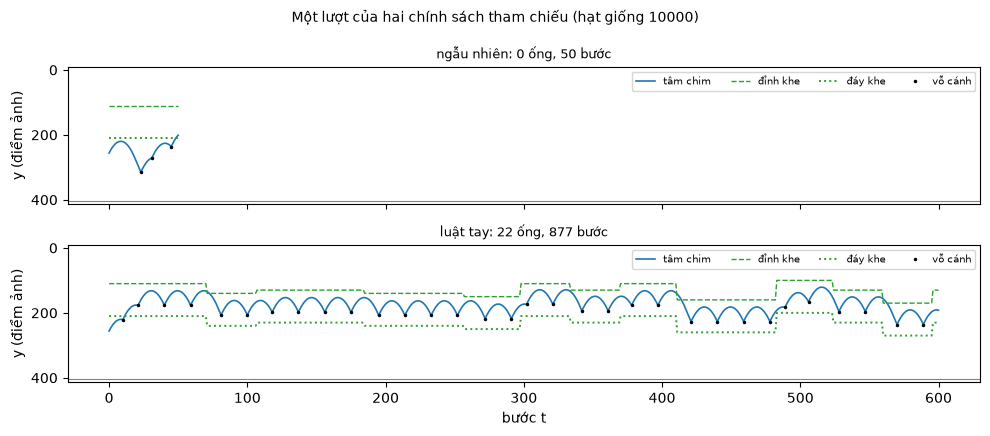

In [7]:
# Ghi lại lượt đầu tiên của EVAL_SEED cho hai mốc rồi vẽ
k_ref = 0
episodes_ref = {name: run_episode(env, pol, EVAL_SEED + k_ref, record=True)
                for name, pol in [("ngẫu nhiên", random_policy), ("luật tay", rule_policy)]}
for name, ep in episodes_ref.items():
    assert ep["length"] == results_ref[name]["length"][k_ref]     # trùng lượt tương ứng trong phép đánh giá
plot_episodes(episodes_ref, f"Một lượt của hai chính sách tham chiếu (hạt giống {EVAL_SEED + k_ref})")
display(flappy_player(episodes_ref))

**Đọc hình.** Chính sách ngẫu nhiên vỗ cánh không theo vị trí khe, nên chim thường rơi xuống đất hoặc chạm ống đầu tiên. Luật tay chỉ dùng hai đại lượng: độ lệch dọc giữa tâm chim và tâm khe, và dấu của $v_y$. Nó giữ tâm chim dao động quanh tâm khe. Luật này không dùng khoảng cách ngang tới ống, nên không chuẩn bị trước cho khe kế tiếp khi khe này cao hoặc thấp hơn nhiều; nhiệm vụ 3 ở phần 12 (thí nghiệm loại bỏ từng khối đặc trưng) đo xem thông tin đó có giúp chính sách học được hay không.

## 4. Đặc trưng trên quan sát liên tục

**Vấn đề.** Giá trị hành động phụ thuộc phi tuyến vào trạng thái: vỗ cánh có lợi khi chim thấp hơn khe và đang rơi, nhưng có hại khi chim đã cao hơn khe. Với $\hat q(s,a,w)=x(s,a)^\top w$, mọi phi tuyến phải nằm sẵn trong đặc trưng.

**Trực giác.** Mười hai biến thô mô tả vị trí tuyệt đối của ống và chim; quyết định lại phụ thuộc chủ yếu vào vị trí tương đối. Bốn đại lượng dẫn xuất $\psi(s)=(\Delta x,\Delta y,v_y,\Delta y_2)$ tính từ quan sát hiện tại gom thông tin đó: $\Delta x$ là khoảng cách ngang tới ống kế tiếp, $\Delta y$ là độ lệch dọc của tâm chim so với tâm khe (dương khi chim thấp hơn), $v_y$ là vận tốc dọc, $\Delta y_2$ là độ lệch so với khe của ống sau đó. Đây vẫn là hàm của quan sát hiện tại, không thêm thông tin mới; chúng chỉ đổi hệ tọa độ.

**Chuẩn hóa.** Mỗi đại lượng dẫn xuất được đưa về $[0,1]$ bằng $z_j=\operatorname{clip}\big((\psi_j-\ell_j)/(h_j-\ell_j),0,1\big)$. Các biên $\ell_j,h_j$ (biến `LO`, `HI`) là phân vị $0{,}5\%$ và $99{,}5\%$ của $200$ lượt chính sách luật tay trộn $\varepsilon=0{,}1$ trên hạt giống 900000+$i$, tách khỏi mọi tập đánh giá của notebook, rồi làm tròn ra phía ngoài. Ô mã ở mục đặc trưng tính lại hai phân vị này và in cạnh `LO`, `HI`.

**Bốn họ đặc trưng** dùng trong notebook:

| Họ | $\phi(s)$ | $p$ |
|---|---|---|
| `raw` | 12 biến thô và hằng $1$ | $13$ |
| `der` | $z(s)$ và hằng $1$ | $5$ |
| `four3` | cơ sở Fourier bậc 3 trên $z(s)$: $\phi_c(s)=\cos(\pi\,c^\top z(s))$, $c\in\{0,1,2,3\}^4$ | $256$ |
| `raw_four3` | ghép `raw` và `four3`, giữ một hằng chung | $268$ |

Thành phần $c=0$ của cơ sở Fourier là hằng $1$. Cơ sở Fourier đầy đủ bậc 3 trên 4 biến có $4^4=256$ thành phần, gồm cả tích chéo như $\cos(\pi(z_2+z_3))$ giữa $\Delta y$ và $v_y$, nên biểu diễn được quan hệ phi tuyến giữa độ lệch, vận tốc và giá trị.

**Họ ghép.** Nối hai vector đặc trưng $\phi=[\phi^{(1)};\phi^{(2)}]$ cho $\hat v=\phi^{(1)\top}w^{(1)}+\phi^{(2)\top}w^{(2)}$, nên lớp hàm của họ ghép là tổng hai không gian con của hai họ. Lớp này chứa cả hai lớp con, nên sai số xấp xỉ tốt nhất không lớn hơn; điều đó không bảo đảm học tốt hơn với dữ liệu và bước học hữu hạn. Bước học $\alpha=\kappa/\mathbb E\lVert x(s,a)\rVert^2$ tính trên vector ghép. Khối Fourier có chuẩn lớn hơn nhiều khối thô ($\mathbb E\lVert\phi\rVert^2$ cỡ $130$ so với cỡ $6$, in ở ô mã của ví dụ tính tay dưới đây), nên với cùng $\alpha$ khối thô thay đổi chậm hơn; thử nghiệm khi soạn với khối thô nhân $4$ (họ `raw_four3b`) cho kết quả kém hơn, xem bảng ở phần 6.

In [8]:
LO = np.array([-0.20, -0.35, -0.90, -0.40])     # biên dưới của (dx, dy, v_y, dy2)
HI = np.array([0.85, 0.25, 1.00, 0.15])         # biên trên


def unit(d):
    return np.clip((d - LO) / (HI - LO), 0.0, 1.0)             # z(s) trong [0,1]^4


def make_raw():
    return (lambda o: np.concatenate([np.asarray(o, float), [1.0]])), 13


def make_der():
    return (lambda o: np.concatenate([unit(derived(o)), [1.0]])), 5


def fourier_coeffs(order, dims=4):
    return np.array(list(itertools.product(range(order + 1), repeat=dims)), float)   # cỡ ((order+1)^dims, dims)


def make_fourier(order=3, dims=4):
    Cf = fourier_coeffs(order, dims)                            # hàng đầu c = 0: thành phần hằng
    return (lambda o: np.cos(np.pi * (Cf @ unit(derived(o))[:dims]))), len(Cf)


def make_concat(*makers):
    # Ghép các khối: bỏ hằng của từng khối (raw, der: hằng ở cuối; Fourier: hằng ở đầu), thêm một hằng chung
    parts = [(mk, *mk()) for mk in makers]
    def phi(o):
        blocks = [(f(o)[1:] if mk is make_fourier else f(o)[:-1]) for mk, f, _ in parts]
        return np.concatenate(blocks + [[1.0]])
    return phi, sum(p - 1 for _, _, p in parts) + 1


# Tái lập LO, HI: phân vị 0,5% và 99,5% của psi(s) trên 200 lượt luật tay trộn epsilon = 0,1 (hạt giống 900000+i)
U_ref = []
for i in range(200):
    o, _ = env.reset(seed=900_000 + i); rng_r = np.random.default_rng(900_000 + i)
    while True:
        U_ref.append(derived(o))
        a = int(rng_r.integers(2)) if rng_r.random() < 0.1 else rule_policy(o)
        o, r, term, trunc, _ = env.step(a)
        if term or trunc:
            break
U_ref = np.array(U_ref)                                          # cỡ (N, 4)
print(f"{len(U_ref)} trạng thái | phân vị 0,5%:", np.round(np.percentile(U_ref, 0.5, axis=0), 3), "| LO:", LO)
print(f"{' ' * len(str(len(U_ref)))}            phân vị 99,5%:", np.round(np.percentile(U_ref, 99.5, axis=0), 3), "| HI:", HI)

FEATS = {"raw": make_raw, "der": make_der, "four3": lambda: make_fourier(3),
         "raw_four3": lambda: make_concat(make_raw, make_fourier)}
for name, mk in FEATS.items():
    phi, p = mk()
    assert phi(obs).shape == (p,)
    print(f"{name:<10} p = {p}")

12186 trạng thái | phân vị 0,5%: [-0.156 -0.309 -0.9   -0.342] | LO: [-0.2  -0.35 -0.9  -0.4 ]
                 phân vị 99,5%: [0.802 0.188 1.    0.107] | HI: [0.85 0.25 1.   0.15]
raw        p = 13
der        p = 5
four3      p = 256
raw_four3  p = 268


**Ví dụ tính tay.** Lấy quan sát `obs` ở cuối phần 2, tính $\psi(s)$, $z(s)$ và một thành phần Fourier $c=(1,0,2,0)$ bằng tay: $\phi_c=\cos\big(\pi(z_1+2z_3)\big)$, rồi so với vector do `phi` trả về. Ô mã cũng in $\mathbb E\lVert\phi\rVert^2$ của từng họ trên một tập lượt nhỏ để thấy thang khác nhau giữa các khối.

In [9]:
psi_s = derived(obs); z_s = unit(psi_s)
print("psi(s) =", np.round(psi_s, 4), "| z(s) =", np.round(z_s, 4))
phi_f, p_f = make_fourier(3)
c_vec = np.array([1, 0, 2, 0.0])
k_c = int(np.flatnonzero((fourier_coeffs(3) == c_vec).all(axis=1))[0])     # vị trí của c trong danh sách hệ số
by_hand = np.cos(np.pi * (z_s[0] + 2 * z_s[2]))
print(f"phi_c(s) với c = {c_vec.astype(int)}: tính tay {by_hand:.5f}, từ phi {phi_f(obs)[k_c]:.5f} (vị trí {k_c})")
assert np.isclose(by_hand, phi_f(obs)[k_c]) and np.isclose(phi_f(obs)[0], 1.0)


def collect_obs(env, n=30, seed=900_000):
    # Quan sát của chính sách ngẫu nhiên p = 0,08 trên hạt giống 900000+i (tách khỏi các tập đánh giá)
    out = []
    for i in range(n):
        out.append(run_episode(env, random_policy, seed + i, record=True)["states"])
    return np.concatenate(out)


OBS_REF = collect_obs(env)
for name, mk in FEATS.items():
    phi, p = mk()
    sq = np.mean([phi(o) @ phi(o) for o in OBS_REF])
    print(f"{name:<10} E||phi||^2 = {sq:7.1f} trên {len(OBS_REF)} quan sát")

psi(s) = [ 0.2465 -0.1172 -0.6    -0.1758] | z(s) = [0.4253 0.388  0.1579 0.4077]
phi_c(s) với c = [1 0 2 0]: tính tay -0.68696, từ phi -0.68696 (vị trí 72)
raw        E||phi||^2 =     6.1 trên 1561 quan sát
der        E||phi||^2 =     2.6 trên 1561 quan sát
four3      E||phi||^2 =   129.6 trên 1561 quan sát


raw_four3  E||phi||^2 =   134.7 trên 1561 quan sát


**Đặc trưng cho cặp trạng thái–hành động.** Như ghi chú Bài 07 (mục 5.2) và bài thực hành Lunar Lander, với $m=2$ hành động và mã one-hot $e_a$,

$$x(s,a)=\begin{bmatrix}\phi(s)\\ e_a\\ \phi(s)\otimes e_a\\ 1\end{bmatrix},\qquad \hat q(s,a,w)=\phi(s)^\top\big(w^{(1)}+u_a\big)+c_a+b.$$

Lớp `LinearQ` lưu $w$ theo bốn khối: `w1` cỡ $(p,)$ cho $\phi(s)$, `U` cỡ $(2,p)$ cho $\phi(s)\otimes e_a$, `c` cỡ $(2,)$ cho $e_a$ và `b` vô hướng. Một cập nhật $w\leftarrow w+\eta\,x(s,a)$ cộng $\eta\phi(s)$ vào `w1` và `U[a]`, cộng $\eta$ vào `c[a]` và `b`. Vì $\phi$ đã chứa thành phần hằng, $\lVert x(s,a)\rVert^2=2\lVert\phi(s)\rVert^2+2$. Ma trận đặc trưng của mã hóa này không đủ hạng cột (ghi chú mục 5.2), nên $w$ không duy nhất nhưng $\hat q$ vẫn xác định.

Chính sách $\varepsilon$-tham lam chọn ngẫu nhiên đều với xác suất $\varepsilon$; còn lại chọn hành động cực đại của $\hat q(s,\cdot,w)$, chia đều khi đồng hạng (như Bài 06).

In [10]:
M = 2   # số hành động


class LinearQ:
    # q_hat(s, a, w) = x(s,a)^T w với w lưu theo bốn khối
    def __init__(self, p):
        self.w1 = np.zeros(p); self.U = np.zeros((M, p)); self.c = np.zeros(M); self.b = 0.0

    def q(self, f):                                    # f = phi(s), cỡ (p,) -> q_hat(s, ., w), cỡ (2,)
        return f @ self.w1 + self.U @ f + self.c + self.b

    def update(self, f, a, step):                      # w <- w + step * x(s,a)
        self.w1 += step * f; self.U[a] += step * f; self.c[a] += step; self.b += step

    def norm(self):                                    # ||w||
        return float(np.sqrt(self.w1 @ self.w1 + (self.U * self.U).sum() + self.c @ self.c + self.b ** 2))


def x_sa(f, a):                                        # x(s,a) viết tường minh, chỉ dùng để kiểm
    e = np.eye(M)[a]
    return np.concatenate([f, e, np.kron(f, e), [1.0]])


def egreedy(qv, eps, rng):
    if eps > 0 and rng.random() < eps:
        return int(rng.integers(M))                    # thăm dò: chọn đều
    G = np.flatnonzero(qv == qv.max())
    return int(G[0]) if len(G) == 1 else int(G[rng.integers(len(G))])   # đồng hạng: chọn đều


# Kiểm: lưu theo khối cho đúng x(s,a)^T w, và ||x(s,a)||^2 = 2||phi||^2 + 2
rng_t = np.random.default_rng(0)
f = phi_f(obs); Qt = LinearQ(p_f)
Qt.w1, Qt.U, Qt.c, Qt.b = rng_t.normal(size=p_f), rng_t.normal(size=(M, p_f)), rng_t.normal(size=M), 0.3
w_vec = np.concatenate([Qt.w1, Qt.c, Qt.U.T.ravel(), [Qt.b]])   # khối Kronecker: vị trí 2i + a ứng với U[a, i]
for a in range(M):
    assert np.isclose(x_sa(f, a) @ w_vec, Qt.q(f)[a])
    assert np.isclose(x_sa(f, a) @ x_sa(f, a), 2 * f @ f + 2)
print("d =", len(x_sa(f, 0)), "| q_hat(s, .) =", np.round(Qt.q(f), 3))

d = 771 | q_hat(s, .) = [12.277 14.055]


## 5. Sarsa và Q-learning tuyến tính

**Vấn đề.** Cần cập nhật $w$ từ từng chuyển $(S,A,R,S')$ mà không biết mô hình. Mục tiêu một bước chứa $\hat q$ tại trạng thái kế tiếp, nên cập nhật là bán gradient: mục tiêu được giữ cố định khi lấy đạo hàm theo $w$ (ghi chú Bài 07, mục 12.3 và 13.1).

$$y=\begin{cases}R, & S'\ \text{kết thúc},\\ R+\gamma\,\hat q(S',A',w) & \text{(Sarsa, } A'\ \text{chọn theo } \varepsilon\text{-tham lam)},\\ R+\gamma\max_{a'}\hat q(S',a',w) & \text{(Q-learning)},\end{cases}\qquad w\leftarrow w+\alpha\big[y-\hat q(S,A,w)\big]\,x(S,A).$$

Vì $\nabla_w\hat q(S,A,w)=x(S,A)$, sau cập nhật giá trị tại chính cặp đó đổi đúng $\alpha\,\delta\,\lVert x(S,A)\rVert^2$, với $\delta=y-\hat q(S,A,w)$. Bước học $\alpha=\kappa/\mathbb E\lVert x\rVert^2$ vì vậy giữ mức thay đổi này ở cỡ $\kappa\,\delta$ bất kể số chiều của họ đặc trưng (Sutton–Barto, ấn bản 2, §9.6).

**Ví dụ tính tay** với $p=2$, $\phi(S)=(1;\,0{,}5)$, $\phi(S')=(1;\,1)$ (thành phần đầu là hằng), $w^{(1)}=(0;0)$, $u_1=(1;0)$, khối hằng của hành động $c_0=c_1=0$, $b=0$, $\gamma=0{,}9$, $\alpha=0{,}1$, chuyển $S\xrightarrow{A=1,\ R=0{,}1}S'$ và hành động kế tiếp của Sarsa $A'=1$. Hai trường hợp khác nhau ở $u_0$:

- **(a)** $u_0=(0;1)$: $\hat q(S,\cdot)=(0{,}5;\ 1)$ và $\hat q(S',\cdot)=(1;\ 1)$. Khi đó $y_{\text{Sarsa}}=0{,}1+0{,}9\cdot\hat q(S',1)=1$ và $y_{\text{Q}}=0{,}1+0{,}9\max(1,1)=1$; cả hai có $\delta=y-\hat q(S,1)=0$, $w$ không đổi.
- **(b)** $u_0=(0;3)$: $\hat q(S,\cdot)=(1{,}5;\ 1)$ và $\hat q(S',\cdot)=(3;\ 1)$. Sarsa dùng hành động đã chọn $A'=1$: $y_{\text{Sarsa}}=0{,}1+0{,}9\cdot1=1$, $\delta=0$. Q-learning dùng cực đại: $y_{\text{Q}}=0{,}1+0{,}9\cdot3=2{,}8$, $\delta=2{,}8-1=1{,}8$. Với $\lVert x(S,1)\rVert^2=2(1+0{,}25)+2=4{,}5$, giá trị mới $\hat q(S,1)=1+0{,}1\cdot1{,}8\cdot4{,}5=1{,}81$; chỉ `w1`, `U[1]`, `c[1]` và `b` đổi.

Trường hợp (b) được kiểm bằng `LinearQ` ở ô mã kế tiếp. 

In [11]:
fS, fS2 = np.array([1.0, 0.5]), np.array([1.0, 1.0])
Qh = LinearQ(2); Qh.U = np.array([[0.0, 3.0], [1.0, 0.0]])          # u_0 = (0, 3), u_1 = (1, 0)
q_S, q_S2 = Qh.q(fS), Qh.q(fS2)
y_sarsa = 0.1 + 0.9 * q_S2[1]                                        # A' = 1
y_q = 0.1 + 0.9 * q_S2.max()
delta = y_q - q_S[1]
U0_before = Qh.U[0].copy()
Qh.update(fS, 1, 0.1 * delta)                                        # w <- w + alpha * delta * x(S, 1)
print("q(S,.) =", q_S, "| q(S',.) =", q_S2, "| y_Sarsa =", y_sarsa, "| y_Q =", round(y_q, 4))
print("q(S,1) sau cập nhật Q-learning:", round(Qh.q(fS)[1], 4))
assert np.allclose(q_S, [1.5, 1.0]) and np.allclose(q_S2, [3.0, 1.0])     # với u_0 = (0, 3)
assert np.isclose(y_sarsa, 1.0) and np.isclose(y_q, 2.8)
assert np.isclose(Qh.q(fS)[1], 1.0 + 0.1 * 1.8 * 4.5) and np.allclose(Qh.U[0], U0_before)

q(S,.) = [1.5 1. ] | q(S',.) = [3. 1.] | y_Sarsa = 1.0 | y_Q = 2.8
q(S,1) sau cập nhật Q-learning: 1.81


**Quy trình** (ghi chú Bài 07, mục 12.5 cho Sarsa, 13.1 cho Q-learning). Đầu vào: họ đặc trưng $\phi$, hằng bước học $\kappa$, lịch $\varepsilon_k$, $\gamma$, $w_0=0$, số lượt $K$.

1. Lượt $k$: `reset` với hạt giống `TRAIN_SEED + k`, tính $\phi(S)$, chọn $A$ theo $\varepsilon_k$-tham lam của $\hat q(S,\cdot,w)$.
2. Thực hiện $A$, nhận $R$, $S'$. Nếu $S'$ kết thúc: $y=R$. Nếu không: Sarsa chọn $A'$ theo $\varepsilon_k$-tham lam của $\hat q(S',\cdot,w)$ với $w$ trước cập nhật và đặt $y=R+\gamma\hat q(S',A',w)$; Q-learning đặt $y=R+\gamma\max_{a'}\hat q(S',a',w)$. Lượt bị cắt ngắn ở $50$ ống vẫn bootstrap.
3. $w\leftarrow w+\alpha[y-\hat q(S,A,w)]\,x(S,A)$.
4. Nếu lượt chưa dừng: Sarsa thực hiện đúng $A'$; Q-learning chọn hành động mới theo $\varepsilon_k$-tham lam với $w$ đã cập nhật. Quay lại bước 2.

Hàm `train_linear` ghi số ống và tổng thưởng của từng lượt huấn luyện cùng $\lVert w\rVert$ sau mỗi lượt. Bước học dùng $\mathbb E\lVert x\rVert^2=2\,\mathbb E\lVert\phi\rVert^2+2$ ước lượng trên $50$ lượt của chính sách ngẫu nhiên (hạt giống 900000+$i$), như trong thử nghiệm khi soạn.

In [12]:
def mean_sqnorm_x(phi, env, n=50, seed=900_000):
    # E||x(s,a)||^2 = 2 E||phi(s)||^2 + 2 trên các trạng thái mà chính sách ngẫu nhiên đi qua
    s = k = 0
    for i in range(n):
        o, _ = env.reset(seed=seed + i); rng = np.random.default_rng(seed + i)
        while True:
            f = phi(o); s += f @ f; k += 1
            o, r, term, trunc, _ = env.step(random_policy(o, rng))
            if term or trunc:
                break
    return 2 * s / k + 2


def linear_eps(k, eps_end=0.01, k_decay=1200):
    return max(eps_end, 1.0 - (1.0 - eps_end) * k / k_decay)          # 1 -> eps_end trong k_decay lượt


def train_linear(algo, phi, p, K, alpha, eps_fn, env_seed=TRAIN_SEED, agent_seed=AGENT_SEED, gamma=GAMMA):
    env_t = make_env(); Q = LinearQ(p); rng = np.random.default_rng(agent_seed)
    log = dict(score=[], total=[], wnorm=[], steps=[])
    for k in range(K):
        eps = eps_fn(k)
        o, _ = env_t.reset(seed=env_seed + k); f = phi(o); qv = Q.q(f)          # bước 1
        a = egreedy(qv, eps, rng); R = 0.0; n_steps = 0
        while True:
            o2, r, term, trunc, info = env_t.step(a); R += r; n_steps += 1       # bước 2
            f2 = phi(o2); q2 = Q.q(f2)                                          # q_hat(S', ., w) trước cập nhật
            if term:
                y = r; a2 = None
            elif algo == "sarsa":
                a2 = egreedy(q2, eps, rng); y = r + gamma * q2[a2]
            else:
                a2 = None; y = r + gamma * q2.max()
            Q.update(f, a, alpha * (y - qv[a]))                                 # bước 3
            if term or trunc:
                break
            f = f2; qv = Q.q(f2)                                                # bước 4
            a = a2 if algo == "sarsa" else egreedy(qv, eps, rng)
        log["score"].append(info["score"]); log["total"].append(R); log["wnorm"].append(Q.norm())
        log["steps"].append(n_steps)                                                 # số cập nhật trong lượt
    return Q, {k: np.array(v) for k, v in log.items()}


def greedy_linear(Q, phi):
    return lambda o, rng: egreedy(Q.q(phi(o)), 0.0, rng)               # chính sách tham lam theo q_hat

## 6. So sánh các họ đặc trưng

**Vấn đề.** Họ đặc trưng quyết định lớp hàm $\{x(s,a)^\top w\}$. Nếu lớp hàm không biểu diễn được sự khác biệt giữa vỗ cánh và không vỗ cánh ở các vùng trạng thái mà chim thường đi qua, chính sách tham lam theo $\hat q$ không thể tốt, dù học bao lâu.

**Thiết lập so sánh.** Bốn họ ở phần 4 được huấn luyện bằng cùng Q-learning, cùng $\kappa=0{,}5$, cùng $K=4000$ lượt, cùng lịch $\varepsilon_k$ giảm tuyến tính từ $1$ xuống $0{,}01$ trong $1200$ lượt đầu, cùng hạt giống huấn luyện. Sau huấn luyện, chính sách tham lam của mỗi họ được đánh giá trên $20$ lượt `VALID_SEED`. Q-learning được dùng cho phép so sánh này vì trong thử nghiệm khi soạn nó cho kết quả cao nhất trên họ ghép ở $K=4000$; Sarsa được huấn luyện ở phần 7 trên họ được chọn.

**Quy tắc chọn** (đặt trước khi chạy): chọn họ có số ống trung bình cao nhất trên `VALID_SEED`; nếu hai họ cách nhau không quá $1{,}96$ lần SE của hiệu ghép cặp thì chọn họ ít chiều hơn. `TEST_SEED` không được dùng cho việc chọn.

Phép so sánh chạy khoảng ba phút; thời gian từng họ được in ra. Ngoài số ống, ô mã in $\lVert w\rVert$ và $\max\lvert\hat q\rvert$ trên các trạng thái tham chiếu `OBS_REF` (phần 4). $\lVert w\rVert$ không so trực tiếp được giữa các họ, vì thang đặc trưng và bước học khác nhau: $\lvert\hat q(s,a,w)\rvert\le\lVert x(s,a)\rVert\,\lVert w\rVert$, và $\lVert x\rVert$ của họ Fourier lớn hơn của họ thô khoảng bốn lần. $\max\lvert\hat q\rvert$ thì so được với miền lợi tức hợp lý: phần thưởng mỗi bước không vượt $1$, nên $\lvert G_t\rvert\le1/(1-\gamma)=100$, và với $+0{,}1$ mỗi bước sống cùng $+1$ mỗi ống (khoảng $36$ bước), lợi tức chiết khấu điển hình chỉ cỡ $10$–$13$.

In [13]:
C_STEP, K_TRAIN, N_VALID = 0.5, 4000, 20
eps_fn = lambda k: linear_eps(k, eps_end=0.01, k_decay=1200)

compare = {}
for name, mk in FEATS.items():
    phi, p = mk()
    alpha = C_STEP / mean_sqnorm_x(phi, env)                     # alpha = kappa / E||x(s,a)||^2
    t0 = time.time()
    Q, log = train_linear("q", phi, p, K_TRAIN, alpha, eps_fn)
    secs = time.time() - t0
    res = evaluate(env, greedy_linear(Q, phi), N_VALID, VALID_SEED)
    compare[name] = dict(Q=Q, log=log, res=res, phi=phi, p=p, alpha=alpha, secs=secs)
    se = res["score"].std(ddof=1) / np.sqrt(N_VALID)
    qabs = max(np.abs(Q.q(phi(o))).max() for o in OBS_REF)            # max |q_hat| trên các trạng thái tham chiếu
    print(f"{name:<10} p = {p:3d} | alpha = {alpha:.2e} | ống (VALID) {res['score'].mean():6.2f} ± {se:5.2f} | "
          f"đạt 50: {100 * res['trunc'].mean():3.0f}% | ||w|| cuối {log['wnorm'][-1]:6.1f}, lớn nhất "
          f"{log['wnorm'].max():6.1f} | max|q| {qabs:6.1f} | {secs:4.0f} giây")

raw        p =  13 | alpha = 3.52e-02 | ống (VALID)   0.40 ±  0.11 | đạt 50:   0% | ||w|| cuối   15.7, lớn nhất   52.0 | max|q|    5.8 |   12 giây


der        p =   5 | alpha = 7.13e-02 | ống (VALID)   0.00 ±  0.00 | đạt 50:   0% | ||w|| cuối    8.1, lớn nhất   38.5 | max|q|    6.0 |   14 giây


four3      p = 256 | alpha = 1.92e-03 | ống (VALID)  34.70 ±  4.24 | đạt 50:  55% | ||w|| cuối    6.9, lớn nhất    6.9 | max|q|   14.4 |   58 giây


raw_four3  p = 268 | alpha = 1.85e-03 | ống (VALID)  25.05 ±  3.50 | đạt 50:  10% | ||w|| cuối    6.2, lớn nhất    6.3 | max|q|   13.2 |   61 giây


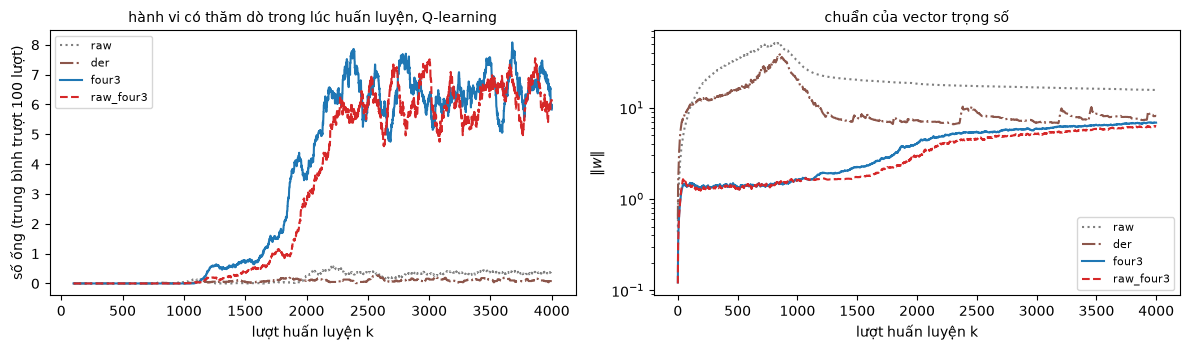

In [14]:
# Đường học: số ống của lượt huấn luyện (trung bình trượt 100 lượt) và ||w|| theo lượt
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
styles = {"raw": ("tab:gray", ":"), "der": ("tab:brown", "-."), "four3": ("tab:blue", "-"),
          "raw_four3": ("tab:red", "--")}
for name, v in compare.items():
    col, ls = styles[name]
    sc = np.convolve(v["log"]["score"], np.ones(100) / 100, mode="valid")      # trung bình trượt 100 lượt
    axes[0].plot(np.arange(100, K_TRAIN + 1), sc, color=col, ls=ls, label=name)
    axes[1].plot(v["log"]["wnorm"], color=col, ls=ls, label=name)
axes[0].set_xlabel("lượt huấn luyện k"); axes[0].set_ylabel("số ống (trung bình trượt 100 lượt)")
axes[0].set_title("hành vi có thăm dò trong lúc huấn luyện, Q-learning", fontsize=10)
axes[1].set_xlabel("lượt huấn luyện k"); axes[1].set_ylabel(r"$\|w\|$"); axes[1].set_yscale("log")
axes[1].set_title("chuẩn của vector trọng số", fontsize=10)
for ax in axes:
    ax.legend(fontsize=8)
fig.tight_layout(); plt.show()

**Thử nghiệm khi soạn (ngoài notebook).** Bảng dưới ghi kết quả chạy trước khi soạn notebook: mỗi cấu hình chạy với $3$ hạt giống huấn luyện ($6$ cho Fourier bậc 3 ở $K=8000$) (hạt giống môi trường $10^6\cdot s$), chính sách tham lam được đánh giá trên $100$ lượt hạt giống 800000+$i$, tách khỏi `VALID_SEED` và `TEST_SEED`. Các cột: họ, thuật toán, $K$, số hạt giống, số ống trung bình và độ lệch chuẩn giữa các hạt giống, tỉ lệ lượt đạt $50$ ống, $\lVert w\rVert$ lớn nhất. Ngoài bốn họ ở trên còn có: `poly2` (đa thức bậc 2 trên $z$, $p=15$), `four3d3` và `four5d3` (Fourier bậc 3 và bậc 5 trên ba biến $(\Delta x,\Delta y,v_y)$, $p=64$ và $216$), `four4` (Fourier bậc 4, $p=625$, chỉ thử với $K=2000$), `raw_der`, `der_four3`, `raw_four3b` (như `raw_four3` nhưng khối thô nhân $4$) và `raw_der_four3`. Bảng đầu chỉ gồm các cấu hình $\kappa=0{,}5$, $K\in\{4000;8000\}$, cùng lịch $\varepsilon_k$ giảm trong $30\%$ số lượt.

Các tổ hợp được thử lấy từ $\kappa\in\{0{,}05;0{,}2;0{,}5;1\}$ và $K\in\{2000;3000;4000;8000\}$, không phải mọi tổ hợp đều có mặt (lưới $K=2000$ giảm $\varepsilon$ trong $50\%$ số lượt), tổng cộng $210$ lần chạy; hai bảng liệt kê đủ các tổ hợp đã thử. Kết quả nhạy với $\kappa$ và $K$: Fourier bậc 3 với Q-learning cho $16{,}3\pm14{,}9$ ống ở $\kappa=1$ so với $36{,}6$ ở $\kappa=0{,}5$ ($K=8000$); với $K=2000$ mọi họ đều dưới $9$ ống; `four3d3` cho $0$ ống ở $\kappa=0{,}5$ nhưng Sarsa đạt $23{,}1$ ở $\kappa=0{,}2$. Cấu hình của phần 6 (bốn họ, Q-learning, $\kappa=0{,}5$, $K=4000$) được chọn từ các bảng này, nên kết quả trên bảng lạc quan cho cấu hình được chọn, và thiên lệch chọn cấu hình gồm cả $\kappa$, $K$ lẫn họ đặc trưng.

In [15]:
TUNE = [   # (họ, thuật toán, K, số hạt giống, ống TB, sd, tỉ lệ đạt 50, ||w|| lớn nhất)
    ("raw", "q", 4000, 3, 0.5, 0.1, 0.00, 81.9),
    ("raw", "q", 8000, 3, 0.0, 0.0, 0.00, 108.8),
    ("raw", "sarsa", 8000, 3, 0.0, 0.0, 0.00, 16.9),
    ("der", "q", 4000, 3, 0.3, 0.3, 0.00, 44.1),
    ("der", "q", 8000, 3, 0.0, 0.0, 0.00, 78.5),
    ("der", "sarsa", 8000, 3, 0.0, 0.0, 0.00, 18.1),
    ("poly2", "q", 8000, 3, 0.0, 0.0, 0.00, 1895.1),
    ("poly2", "sarsa", 8000, 3, 0.0, 0.0, 0.00, 15.1),
    ("raw_der", "q", 8000, 3, 0.0, 0.0, 0.00, 166.1),
    ("raw_der", "sarsa", 8000, 3, 0.0, 0.0, 0.00, 13.2),
    ("four3", "q", 4000, 3, 36.3, 1.4, 0.50, 6.7),
    ("four3", "q", 8000, 6, 36.6, 4.3, 0.54, 8.8),
    ("four3", "sarsa", 4000, 3, 35.0, 3.6, 0.51, 5.4),
    ("four3", "sarsa", 8000, 6, 29.7, 13.3, 0.39, 6.9),
    ("four3d3", "q", 8000, 3, 0.0, 0.0, 0.00, 4.0),
    ("four3d3", "sarsa", 8000, 3, 0.0, 0.0, 0.00, 3.4),
    ("four5d3", "q", 8000, 3, 30.7, 10.1, 0.38, 8.1),
    ("four5d3", "sarsa", 8000, 3, 35.1, 6.9, 0.49, 6.0),
    ("der_four3", "q", 8000, 3, 20.3, 11.4, 0.17, 8.6),
    ("der_four3", "sarsa", 8000, 3, 23.1, 13.5, 0.24, 6.5),
    ("raw_four3", "q", 4000, 3, 39.2, 5.1, 0.62, 6.6),
    ("raw_four3", "q", 8000, 3, 36.7, 4.7, 0.54, 8.2),
    ("raw_four3", "sarsa", 4000, 3, 33.4, 7.5, 0.45, 5.1),
    ("raw_four3", "sarsa", 8000, 3, 25.1, 6.4, 0.22, 6.6),
    ("raw_four3b", "q", 8000, 3, 29.5, 8.7, 0.35, 7.2),
    ("raw_four3b", "sarsa", 8000, 3, 21.5, 6.3, 0.14, 5.5),
    ("raw_der_four3", "q", 8000, 3, 13.1, 9.2, 0.06, 8.4),
    ("raw_der_four3", "sarsa", 8000, 3, 26.6, 6.8, 0.32, 6.6),
]
print(f"{'họ':<14}{'thuật toán':<11}{'K':>6}{'n':>3}{'ống TB':>8}{'sd':>7}{'đạt 50':>8}{'||w|| max':>11}")
for fk, algo, K, n, m, sd, tr, wm in TUNE:
    print(f"{fk:<14}{('Q-learning' if algo == 'q' else 'Sarsa'):<11}{K:>6}{n:>3}{m:>8.1f}{sd:>7.1f}{tr:>8.2f}{wm:>11.1f}")

TUNE_OTHER = [   # (họ, thuật toán, kappa, K, tỉ lệ số lượt giảm epsilon, số hạt giống, ống TB, sd)
    ("der", "q", 0.05, 2000, 0.5, 3, 0.0, 0.0),
    ("der", "sarsa", 0.05, 2000, 0.5, 3, 0.5, 0.4),
    ("poly2", "q", 0.05, 2000, 0.5, 3, 0.0, 0.0),
    ("poly2", "sarsa", 0.05, 2000, 0.5, 3, 0.0, 0.0),
    ("four3", "q", 0.05, 2000, 0.5, 3, 0.0, 0.0),
    ("four3", "sarsa", 0.05, 2000, 0.5, 3, 0.8, 0.8),
    ("four4", "q", 0.05, 2000, 0.5, 3, 0.2, 0.3),
    ("four4", "sarsa", 0.05, 2000, 0.5, 3, 1.6, 1.1),
    ("four3d3", "q", 0.05, 2000, 0.5, 3, 0.0, 0.0),
    ("four3d3", "sarsa", 0.05, 2000, 0.5, 3, 0.0, 0.0),
    ("der", "q", 0.2, 2000, 0.5, 3, 0.0, 0.0),
    ("der", "sarsa", 0.2, 2000, 0.5, 3, 0.0, 0.0),
    ("poly2", "q", 0.2, 2000, 0.5, 3, 0.0, 0.0),
    ("poly2", "sarsa", 0.2, 2000, 0.5, 3, 0.0, 0.0),
    ("four3", "q", 0.2, 2000, 0.5, 3, 0.3, 0.3),
    ("four3", "sarsa", 0.2, 2000, 0.5, 3, 4.3, 3.1),
    ("four4", "q", 0.2, 2000, 0.5, 3, 1.0, 0.2),
    ("four4", "sarsa", 0.2, 2000, 0.5, 3, 1.5, 0.8),
    ("four3d3", "q", 0.2, 2000, 0.5, 3, 8.8, 14.7),
    ("four3d3", "sarsa", 0.2, 2000, 0.5, 3, 0.3, 0.5),
    ("raw", "q", 0.5, 3000, 0.3, 3, 0.4, 0.1),
    ("der", "q", 0.5, 3000, 0.3, 3, 0.0, 0.0),
    ("four3", "q", 0.5, 3000, 0.3, 3, 26.3, 23.9),
    ("raw_four3", "q", 0.5, 3000, 0.3, 3, 29.0, 13.5),
    ("raw", "q", 0.2, 8000, 0.3, 3, 0.4, 0.1),
    ("raw", "sarsa", 0.2, 8000, 0.3, 3, 0.0, 0.0),
    ("four3", "q", 0.2, 8000, 0.3, 3, 23.3, 11.3),
    ("four3", "sarsa", 0.2, 8000, 0.3, 3, 30.3, 11.0),
    ("four3d3", "q", 0.2, 8000, 0.3, 3, 6.1, 5.6),
    ("four3d3", "sarsa", 0.2, 8000, 0.3, 3, 23.1, 20.0),
    ("four5d3", "q", 0.2, 8000, 0.3, 3, 16.2, 17.9),
    ("four5d3", "sarsa", 0.2, 8000, 0.3, 3, 29.7, 3.4),
    ("raw", "q", 1.0, 8000, 0.3, 3, 0.1, 0.1),
    ("raw", "sarsa", 1.0, 8000, 0.3, 3, 0.0, 0.1),
    ("four3", "q", 1.0, 8000, 0.3, 3, 16.3, 14.9),
    ("four3", "sarsa", 1.0, 8000, 0.3, 3, 17.9, 17.7),
    ("four3d3", "q", 1.0, 8000, 0.3, 3, 0.0, 0.0),
    ("four3d3", "sarsa", 1.0, 8000, 0.3, 3, 0.9, 1.0),
    ("four5d3", "q", 1.0, 8000, 0.3, 3, 25.9, 20.5),
    ("four5d3", "sarsa", 1.0, 8000, 0.3, 3, 2.2, 1.1),
]
print(f"\nCác cấu hình còn lại của lưới\n{'họ':<14}{'thuật toán':<11}{'kappa':>6}{'K':>6}{'giảm eps':>9}{'n':>3}{'ống TB':>8}{'sd':>7}")
for fk, algo, kap, K, fr, n, m, sd in TUNE_OTHER:
    print(f"{fk:<14}{('Q-learning' if algo == 'q' else 'Sarsa'):<11}{kap:>6}{K:>6}{fr:>9}{n:>3}{m:>8.1f}{sd:>7.1f}")

họ            thuật toán      K  n  ống TB     sd  đạt 50  ||w|| max
raw           Q-learning   4000  3     0.5    0.1    0.00       81.9
raw           Q-learning   8000  3     0.0    0.0    0.00      108.8
raw           Sarsa        8000  3     0.0    0.0    0.00       16.9
der           Q-learning   4000  3     0.3    0.3    0.00       44.1
der           Q-learning   8000  3     0.0    0.0    0.00       78.5
der           Sarsa        8000  3     0.0    0.0    0.00       18.1
poly2         Q-learning   8000  3     0.0    0.0    0.00     1895.1
poly2         Sarsa        8000  3     0.0    0.0    0.00       15.1
raw_der       Q-learning   8000  3     0.0    0.0    0.00      166.1
raw_der       Sarsa        8000  3     0.0    0.0    0.00       13.2
four3         Q-learning   4000  3    36.3    1.4    0.50        6.7
four3         Q-learning   8000  6    36.6    4.3    0.54        8.8
four3         Sarsa        4000  3    35.0    3.6    0.51        5.4
four3         Sarsa        8000  6

**Đọc kết quả** (trong lần chạy này, một hạt giống huấn luyện; số theo output):

- Hai họ chỉ tuyến tính theo biến thô (`raw`) hoặc theo đại lượng dẫn xuất (`der`) cho $0{,}40$ và $0{,}00$ ống trên `VALID_SEED`: chính sách tham lam gần như không qua ống nào. $\max\lvert\hat q\rvert$ trên các trạng thái tham chiếu của hai họ này là $5{,}8$ và $6{,}0$, so với $14{,}4$ và $13{,}2$ ở hai họ có cơ sở Fourier và miền lợi tức điển hình cỡ $10$–$13$. Giá trị ước lượng của hai họ đơn giản không lớn bất thường; kết quả kém của chúng nằm ở hình dạng của $\hat q$ theo trạng thái (xem câu hỏi dưới). $\lVert w\rVert$ không so được giữa các họ vì thang khác nhau. Trong cùng một họ, bảng thử nghiệm cho $\lVert w\rVert$ lớn nhất của Q-learning lớn hơn của Sarsa: `raw` $108{,}8$ so với $16{,}9$, `der` $78{,}5$ so với $18{,}1$, `poly2` $1895{,}1$ so với $15{,}1$ ($K=8000$); khác biệt này có thể liên quan tới phép cực đại trong mục tiêu khác chính sách (phần 10). Các họ `raw`, `der`, `poly2`, `raw_der` đều dưới $1$ ống trong bảng.
- Fourier bậc 3 cho $34{,}70\pm4{,}24$ ống ($55\%$ lượt đạt $50$ ống); họ ghép `raw_four3` cho $25{,}05\pm3{,}50$ ($10\%$). Trong lần chạy này, ghép thêm khối biến thô không giúp. Trong bảng thử nghiệm, `raw_four3` cao hơn `four3` ở $K=4000$ ($39{,}2$ so với $36{,}3$ trung bình ba hạt giống), nhưng chênh lệch nhỏ hơn độ lệch chuẩn giữa các hạt giống ($5{,}1$); các họ ghép khác (`der_four3`, `raw_der_four3`, `raw_four3b`) đều thấp hơn `four3`. Mở rộng lớp hàm bằng cách ghép khối không tự cải thiện kết quả khi ngân sách huấn luyện và bước học cố định.
- Mỗi họ chỉ được đánh giá trên $20$ lượt, nên SE lớn; phần 8 dùng $100$ lượt `TEST_SEED` cho họ được chọn.

**Lớp chính sách của `der`.** Với `der`, hiệu giữa hai hành động là $\hat q(s,1,w)-\hat q(s,0,w)=\phi(s)^\top(u_1-u_0)+c_1-c_0$, một hàm afin của $z(s)$. Chính sách tham lam vì vậy chia không gian $z$ bằng một siêu phẳng: vỗ cánh ở một phía, không vỗ ở phía kia. Lớp chính sách này chứa các luật có dạng "vỗ khi $\theta^\top\psi(s)>\theta_0$" (trong miền không bị cắt biên của $z$). Hai luật như vậy được đánh giá dưới đây trên cùng $20$ lượt `VALID_SEED`; các ngưỡng được chọn khi soạn trên $30$ lượt hạt giống 700000+$i$, tách khỏi các tập của notebook.

In [16]:
affine = {"vỗ khi Δy > 0,04": lambda o, rng=None: int(derived(o)[1] > 0.04),
          "vỗ khi Δy + 0,02 v_y > 0,06": lambda o, rng=None: int(derived(o)[1] + 0.02 * derived(o)[2] > 0.06)}
res_aff = {name: evaluate(env, pol, N_VALID, VALID_SEED) for name, pol in affine.items()}
res_aff["Q-learning trên der"] = compare["der"]["res"]
for name, res in res_aff.items():
    se = res["score"].std(ddof=1) / np.sqrt(N_VALID)
    print(f"{name:<28} ống (VALID) {res['score'].mean():6.2f} ± {se:5.2f}")

vỗ khi Δy > 0,04             ống (VALID)  35.20 ±  3.81
vỗ khi Δy + 0,02 v_y > 0,06  ống (VALID)  32.65 ±  3.85
Q-learning trên der          ống (VALID)   0.00 ±  0.00


**Câu hỏi:** Theo output trên, lớp chính sách tham lam của `der` chứa những luật qua được nhiều ống, nhưng Q-learning tuyến tính trên họ này không tìm ra chúng. Giải thích nguyên nhân.

<details><summary>Lời giải</summary>

Q-learning không chọn $w$ để tối ưu chính sách. Nó chọn $w$ để $\hat q(s,a,w)$ xấp xỉ giá trị hành động, thông qua mục tiêu bootstrap $R+\gamma\max_{a'}\hat q(S',a',w)$ và phép chiếu lên lớp hàm tuyến tính theo $\phi$. Giá trị hành động thật phụ thuộc phi tuyến vào $z$: nó cao khi chim nằm trong dải an toàn của khe và giảm nhanh khi chim lệch lên hoặc xuống, nên một hàm afin của $z$ xấp xỉ nó kém. Siêu phẳng quyết định của hàm afin xấp xỉ tốt nhất (theo nghĩa của thuật toán) không trùng với siêu phẳng của luật tốt; mục tiêu bootstrap lấy cực đại trên các ước lượng sai có thể làm sai lệch này lớn thêm (bảng thử nghiệm cho Sarsa trên `der` cũng $0$ ống, nên phép cực đại không phải nguyên nhân duy nhất). Cơ sở Fourier mở rộng lớp hàm, giảm sai số xấp xỉ của $\hat q$, nên chính sách tham lam suy ra từ $\hat q$ gần với chính sách tốt hơn. Một lớp chính sách chứa chính sách tốt chưa đủ để phương pháp dựa trên giá trị tìm ra nó; lớp hàm giá trị phải xấp xỉ được $q$ ở những vùng quyết định.
</details>

**Câu hỏi:** Lớp hàm của họ ghép `raw_four3` chứa lớp hàm của `four3` (đặt trọng số của khối thô bằng $0$). Giải thích vì sao trong lần chạy này `raw_four3` vẫn cho ít ống hơn `four3`.

<details><summary>Lời giải</summary>

Lớp hàm lớn hơn chỉ bảo đảm sai số xấp xỉ tốt nhất không lớn hơn; nó không bảo đảm thuật toán tìm được $w$ tốt hơn. Ba yếu tố có thể làm kết quả kém hơn. (1) Bước học: $\alpha=\kappa/\mathbb E\lVert x\rVert^2$ tính trên vector ghép, nên mức thay đổi của mỗi khối phụ thuộc thang của khối; khối thô có chuẩn nhỏ hơn nhiều khối Fourier, và các biến thô có thể kéo cập nhật theo hướng không có ích trong giai đoạn đầu. (2) Dữ liệu hữu hạn: thêm chiều làm tăng phương sai của ước lượng với cùng $K=4000$ lượt. (3) Biến thiên theo hạt giống: bảng thử nghiệm cho `raw_four3` cao hơn `four3` ở $K=4000$ trung bình ba hạt giống, với độ lệch chuẩn cỡ hiệu giữa hai họ, nên một lần chạy đơn lẻ có thể cho thứ tự ngược lại. Nhiệm vụ 4 và 6 ở phần 12 tách các yếu tố này.
</details>

## 7. Chọn họ đặc trưng và huấn luyện Sarsa

Theo quy tắc ở phần 6, họ được chọn là họ có số ống trung bình cao nhất trên `VALID_SEED`; nếu họ đứng sau cách không quá $1{,}96$ lần SE của hiệu ghép cặp và có ít chiều hơn thì chọn họ đó. Q-learning của họ được chọn được dùng lại; Sarsa được huấn luyện trên cùng họ, cùng $\kappa$, cùng lịch $\varepsilon_k$, cùng $K$ và cùng hạt giống huấn luyện, nên hai thuật toán gặp cùng dãy lượt huấn luyện.

xếp hạng theo VALID: ['four3', 'raw_four3', 'raw', 'der'] -> họ được chọn: four3


Sarsa trên four3: 55 giây
Sarsa       ||w|| cuối 5.08, lớn nhất 5.23
Q-learning  ||w|| cuối 6.86, lớn nhất 6.91


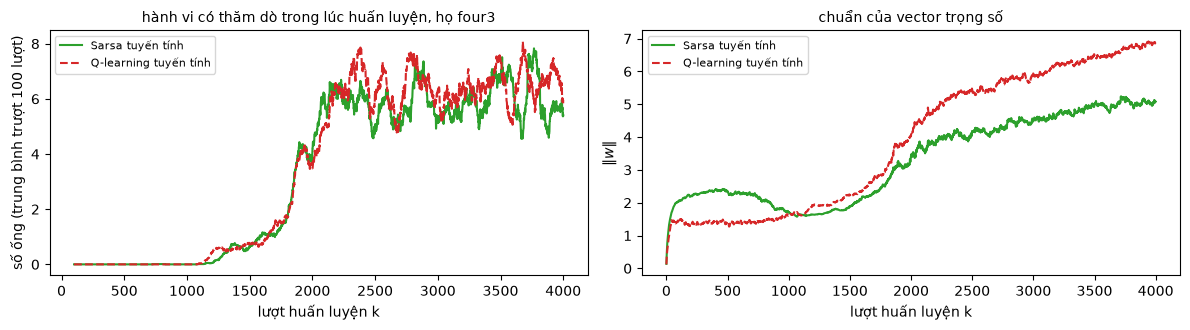

In [17]:
ranked = sorted(compare, key=lambda n: -compare[n]["res"]["score"].mean())
best = ranked[0]
for other in ranked[1:]:                                      # họ ít chiều hơn và không kém rõ rệt thì được chọn
    m, h = paired_difference(compare[best]["res"], compare[other]["res"])
    if compare[other]["p"] < compare[best]["p"] and m <= h:
        best = other
print("xếp hạng theo VALID:", ranked, "-> họ được chọn:", best)

phi_b, p_b, alpha_b = compare[best]["phi"], compare[best]["p"], compare[best]["alpha"]
t0 = time.time()
Q_sarsa, log_sarsa = train_linear("sarsa", phi_b, p_b, K_TRAIN, alpha_b, eps_fn)
print(f"Sarsa trên {best}: {time.time() - t0:.0f} giây")
for name, (Q, log) in {"Sarsa": (Q_sarsa, log_sarsa), "Q-learning": (compare[best]["Q"], compare[best]["log"])}.items():
    print(f"{name:<11} ||w|| cuối {log['wnorm'][-1]:.2f}, lớn nhất {log['wnorm'].max():.2f}")
trained = {"Sarsa tuyến tính": (Q_sarsa, log_sarsa), "Q-learning tuyến tính": (compare[best]["Q"], compare[best]["log"])}

fig, axes = plt.subplots(1, 2, figsize=(12, 3.4))
for (name, (Q, log)), (col, ls) in zip(trained.items(), [("tab:green", "-"), ("tab:red", "--")]):
    axes[0].plot(np.arange(100, K_TRAIN + 1), np.convolve(log["score"], np.ones(100) / 100, mode="valid"),
                 color=col, ls=ls, label=name)
    axes[1].plot(log["wnorm"], color=col, ls=ls, label=name)
axes[0].set_xlabel("lượt huấn luyện k"); axes[0].set_ylabel("số ống (trung bình trượt 100 lượt)")
axes[0].set_title(f"hành vi có thăm dò trong lúc huấn luyện, họ {best}", fontsize=10)
axes[1].set_xlabel("lượt huấn luyện k"); axes[1].set_ylabel(r"$\|w\|$")
axes[1].set_title("chuẩn của vector trọng số", fontsize=10)
for ax in axes:
    ax.legend(fontsize=8)
fig.tight_layout(); plt.show()

**Đọc đường học** (trong lần chạy này). Họ được chọn là `four3`. Số ống của các lượt huấn luyện chỉ khoảng $5$–$8$ sau lượt $2000$, thấp hơn nhiều so với số ống của chính sách tham lam ở phần 6 và 8. Hành vi lúc huấn luyện có thăm dò: với $\varepsilon_k=0{,}01$ và hai hành động chọn đều khi thăm dò, mỗi bước có xác suất $0{,}005$ thực hiện hành động khác hành động tham lam, nên một lượt $1000$ bước có xác suất $1-0{,}995^{1000}\approx0{,}99$ chứa ít nhất một bước như vậy. Trong Flappy Bird một lần vỗ cánh sai lúc có thể đưa chim vào ống, nên lượt huấn luyện thường dừng sớm. Đường học của Sarsa và Q-learning gần nhau; $\lVert w\rVert$ của Q-learning lớn hơn ($6{,}9$ so với $5{,}1$ ở cuối, in ở ô mã trên) và cả hai tăng chậm, không tiến ra vô cùng trong $4000$ lượt.

## 8. Đánh giá cuối

Bốn chính sách được đánh giá trên cùng $100$ lượt `TEST_SEED`, chưa dùng ở bất kỳ bước nào trước đó: hai mốc của phần 3 và hai chính sách tham lam theo $\hat q$ sau $K$ lượt huấn luyện. Thời điểm dừng $K$ được đặt trước. Số ống là thước đo chính; tổng thưởng và $G_0$ cũng được in.

In [18]:
N_TEST = 100
final_policies = {"ngẫu nhiên": random_policy, "luật tay": rule_policy,
                  "Sarsa tuyến tính": greedy_linear(Q_sarsa, phi_b),
                  "Q-learning tuyến tính": greedy_linear(compare[best]["Q"], phi_b)}
t0 = time.time()
final = {name: evaluate(env, pol, N_TEST, TEST_SEED) for name, pol in final_policies.items()}
print(f"{N_TEST} lượt mỗi chính sách, cùng tập hạt giống TEST_SEED; trung bình ± SE ({time.time() - t0:.0f} giây)")
for name, res in final.items():
    summarize(name, res)
print("G_0 trung bình:", {k: round(float(v["G0"].mean()), 2) for k, v in final.items()})
print()
for a_, b_ in [("Sarsa tuyến tính", "ngẫu nhiên"), ("Q-learning tuyến tính", "ngẫu nhiên"),
               ("Sarsa tuyến tính", "luật tay"), ("Q-learning tuyến tính", "luật tay"),
               ("Q-learning tuyến tính", "Sarsa tuyến tính")]:
    m, h = paired_difference(final[a_], final[b_])
    print(f"{a_} - {b_} (số ống): {m:6.2f} ± {h:5.2f} (khoảng 95%, ghép cặp)")

100 lượt mỗi chính sách, cùng tập hạt giống TEST_SEED; trung bình ± SE (18 giây)
ngẫu nhiên               ống   0.03 ±  0.02 | tổng thưởng     3.7 ±   0.1 | dài    49.1 | đạt 50 ống    0%
luật tay                 ống  34.30 ±  1.30 | tổng thưởng   163.4 ±   6.0 | dài  1334.0 | đạt 50 ống   23%
Sarsa tuyến tính         ống  38.04 ±  1.61 | tổng thưởng   180.2 ±   7.5 | dài  1464.6 | đạt 50 ống   55%
Q-learning tuyến tính    ống  28.86 ±  1.98 | tổng thưởng   137.5 ±   9.2 | dài  1123.0 | đạt 50 ống   34%
G_0 trung bình: {'ngẫu nhiên': 3.11, 'luật tay': 11.56, 'Sarsa tuyến tính': 11.41, 'Q-learning tuyến tính': 10.65}

Sarsa tuyến tính - ngẫu nhiên (số ống):  38.01 ±  3.15 (khoảng 95%, ghép cặp)
Q-learning tuyến tính - ngẫu nhiên (số ống):  28.83 ±  3.87 (khoảng 95%, ghép cặp)
Sarsa tuyến tính - luật tay (số ống):   3.74 ±  2.90 (khoảng 95%, ghép cặp)
Q-learning tuyến tính - luật tay (số ống):  -5.44 ±  4.19 (khoảng 95%, ghép cặp)
Q-learning tuyến tính - Sarsa tuyến tính (số ống):  -9.18

**Đọc kết quả** (trong lần chạy này, một hạt giống huấn luyện; số theo output):

- Cả hai chính sách học được vượt rõ chính sách ngẫu nhiên: hiệu ghép cặp $38{,}01\pm3{,}15$ (Sarsa) và $28{,}83\pm3{,}87$ (Q-learning) ống.
- So với luật tay ($34{,}30$ ống): Sarsa tuyến tính cho $38{,}04$ ống, hiệu $3{,}74\pm2{,}90$, khoảng không chứa $0$ nhưng sát $0$; $55\%$ lượt đạt $50$ ống so với $23\%$ của luật tay. Q-learning tuyến tính cho $28{,}86$ ống, hiệu $-5{,}44\pm4{,}19$. Hiệu Q-learning − Sarsa là $-9{,}18\pm4{,}50$. Có năm khoảng tin cậy trên cùng dữ liệu, nên các khoảng sát $0$ cần đọc thận trọng.
- Trong bảng thử nghiệm (ba hạt giống, tập hạt giống khác), cùng cấu hình `four3`, $K=4000$ cho Q-learning $36{,}3\pm1{,}4$ và Sarsa $35{,}0\pm3{,}6$ ống. Kết quả Q-learning ở đây thấp hơn cả ba lần thử đó, nên thứ tự Sarsa > Q-learning trong lần chạy này chưa đủ để kết luận về hai thuật toán; nhiệm vụ 6 ở phần 12 đo lại trên nhiều hạt giống.
- $G_0$ của luật tay và hai chính sách học được gần nhau (khoảng $10{,}7$–$11{,}6$) dù số ống khác nhau. Với $\gamma=0{,}99$, trọng số $\gamma^t$ còn khoảng $0{,}37$ sau $100$ bước, tức khoảng ba ống, nên $G_0$ phân biệt kém các chính sách đều sống qua vài ống đầu. Vì vậy số ống là thước đo chính của bài.

## 9. Trực quan hóa các chính sách sau huấn luyện

### 9.1. Một lượt của bốn chính sách

Lượt được vẽ là lượt đầu tiên của `TEST_SEED`, chọn trước khi xem kết quả. Bốn chính sách gặp cùng dãy ống. Trình phát hiển thị tối đa $900$ bước đầu; dòng trạng thái ghi tổng số bước và số ống của cả lượt khi lượt dài hơn.

ngẫu nhiên               0 ống,    53 bước, va chạm
luật tay                35 ống,  1365 bước, va chạm
Sarsa tuyến tính        46 ống,  1781 bước, va chạm
Q-learning tuyến tính   46 ống,  1781 bước, va chạm
tỉ lệ bước có độ cao chim khác nhau giữa Sarsa và Q-learning: 0.98


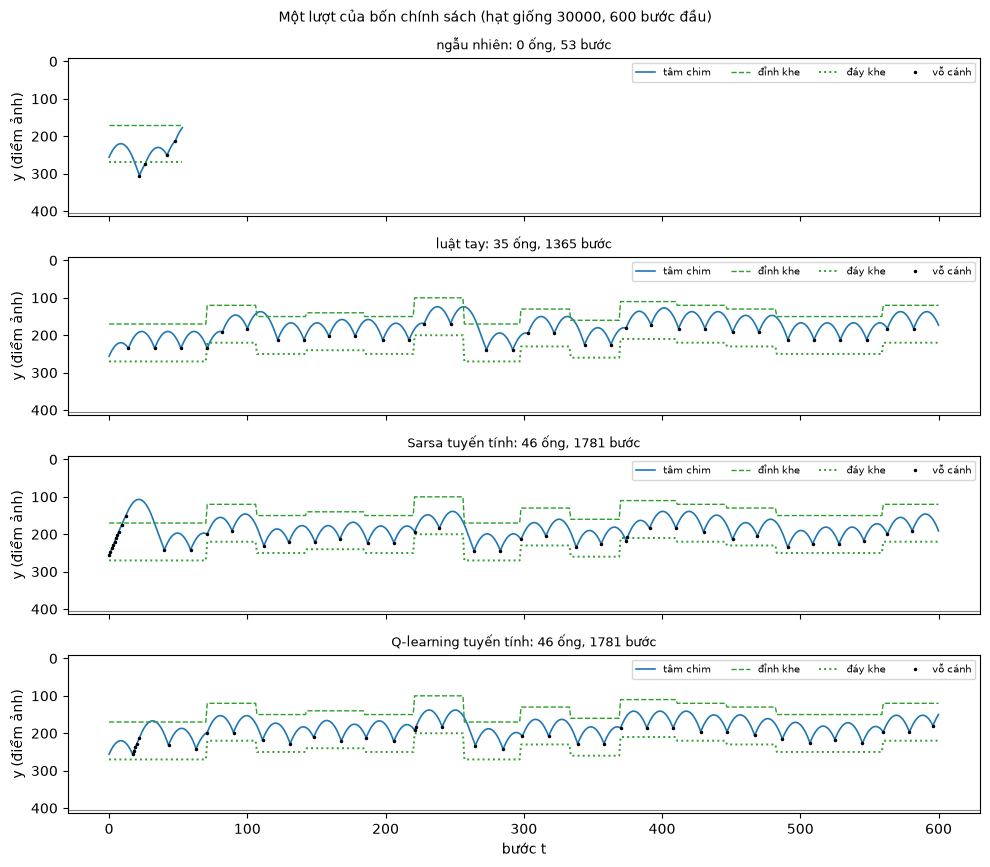

In [19]:
k_viz = 0
episodes_final = {name: run_episode(env, pol, TEST_SEED + k_viz, record=True) for name, pol in final_policies.items()}
for name, ep in episodes_final.items():
    assert ep["length"] == final[name]["length"][k_viz]       # trùng lượt tương ứng trong đánh giá cuối
    print(f"{name:<22} {ep['score']:3d} ống, {ep['length']:5d} bước, " + ("đạt giới hạn" if ep["truncated"] else "va chạm"))
ys_s = episodes_final["Sarsa tuyến tính"]["states"][:, 9]; ys_q = episodes_final["Q-learning tuyến tính"]["states"][:, 9]
n_c = min(len(ys_s), len(ys_q))                              # so quỹ đạo của hai chính sách học được bước theo bước
print(f"tỉ lệ bước có độ cao chim khác nhau giữa Sarsa và Q-learning: {np.mean(ys_s[:n_c] != ys_q[:n_c]):.2f}")
plot_episodes(episodes_final, f"Một lượt của bốn chính sách (hạt giống {TEST_SEED + k_viz}, 600 bước đầu)")
display(flappy_player(episodes_final))

### 9.2. Giá trị hành động ước lượng so với lợi tức thực tế

**Vấn đề.** $\max_a\hat q(S_t,a,w)$ là giá trị mà bảng trọng số gán cho trạng thái khi chọn hành động tốt nhất theo chính nó. So với lợi tức chiết khấu thực tế $G_t=\sum_{j\ge0}\gamma^jR_{t+j+1}$ của chính sách tham lam, đại lượng này cho biết hàm học được đánh giá cao hay thấp. Hai đích khác nhau: Sarsa cập nhật theo hành động kế tiếp của chính sách hành vi $\varepsilon$-tham lam, nên $\hat q$ hướng tới giá trị của chính sách có thăm dò; Q-learning dùng phép cực đại, nhắm tới $q_*$, nhưng với xấp xỉ hàm không có bảo đảm về điểm dừng (mục 10). Với lượt bị cắt ngắn, $G_t$ thiếu phần sau giới hạn $50$ ống, nên so sánh ở cuối lượt dài bị lệch xuống.

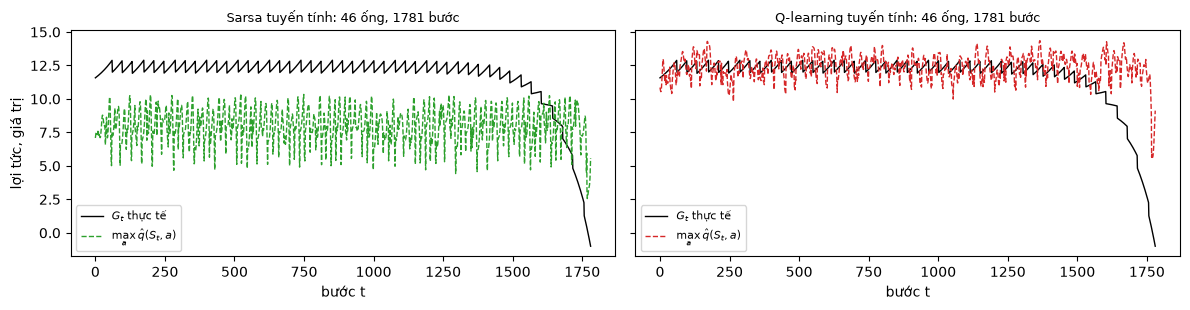

Sarsa tuyến tính       trung bình max_a q(S_0,.) =   7.32, G_0 =  11.41, hiệu  -4.09 ±  0.15
Q-learning tuyến tính  trung bình max_a q(S_0,.) =  11.38, G_0 =  10.65, hiệu   0.73 ±  0.40


In [20]:
def returns_from(rewards, gamma=GAMMA):
    G = np.zeros(len(rewards) + 1)
    for t in range(len(rewards) - 1, -1, -1):          # G_t = R_{t+1} + gamma G_{t+1}
        G[t] = rewards[t] + gamma * G[t + 1]
    return G[:-1]


fig, axes = plt.subplots(1, 2, figsize=(12, 3.2), sharey=True)
for ax, (name, (Q, _)), col in zip(axes, trained.items(), ["tab:green", "tab:red"]):
    ep = episodes_final[name]
    G = returns_from(ep["rewards"])
    qmax = np.array([Q.q(phi_b(o)).max() for o in ep["states"][:-1]])   # max_a q_hat(S_t, a, w)
    ax.plot(G, color="k", lw=1, label="$G_t$ thực tế")
    ax.plot(qmax, color=col, ls="--", lw=1, label=r"$\max_a\hat q(S_t,a)$")
    ax.set_title(f"{name}: {ep['score']} ống, {ep['length']} bước", fontsize=9); ax.set_xlabel("bước t")
    ax.legend(fontsize=8)
axes[0].set_ylabel("lợi tức, giá trị")
fig.tight_layout(); plt.show()

for name, (Q, _) in trained.items():                  # trên 100 lượt TEST_SEED: max_a q_hat(S_0, .) so với G_0
    q0 = np.array([Q.q(phi_b(env.reset(seed=TEST_SEED + i)[0])).max() for i in range(N_TEST)])
    d = q0 - final[name]["G0"]
    print(f"{name:<22} trung bình max_a q(S_0,.) = {q0.mean():6.2f}, G_0 = {final[name]['G0'].mean():6.2f}, "
          f"hiệu {d.mean():6.2f} ± {1.96 * d.std(ddof=1) / np.sqrt(N_TEST):5.2f}")

### 9.3. Chính sách tham lam trên một lát cắt trạng thái

Hình dưới giữ nguyên một quan sát thật của lượt ở 9.1 (khi chim còn cách ống kế tiếp một đoạn) và chỉ thay độ cao chim $y$ cùng vận tốc dọc $v_y$, rồi tô hành động tham lam: ô "V" là vỗ cánh, ô trống là không vỗ. Hai đường nét đứt là độ cao mà tại đó tâm chim ngang đỉnh khe và ngang đáy khe của ống kế tiếp. Luật tay của phần 3 vỗ cánh ở vùng phía dưới tâm khe khi $v_y>0$. Ô mã thứ hai đo trên $20$ lượt đầu của `TEST_SEED` tỉ lệ bước mà tâm chim cao hơn đỉnh khe, để biết vùng phía trên khe có được chính sách tham lam ghé thường xuyên hay không.

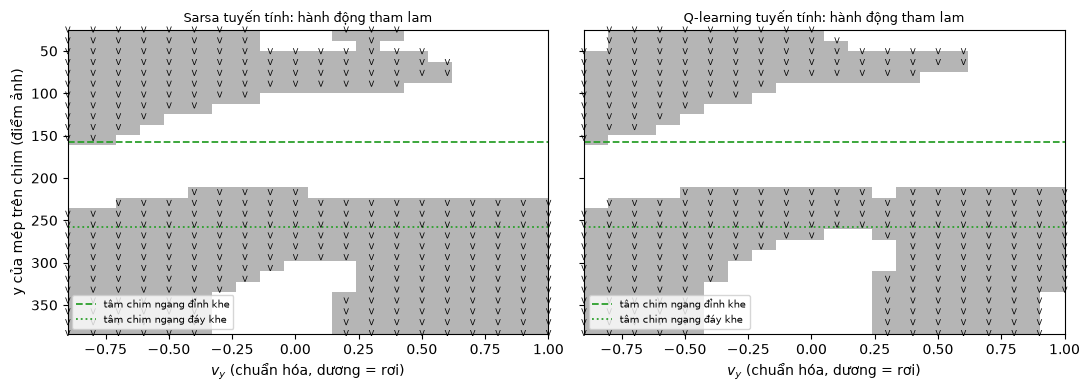

In [21]:
ep_sl = episodes_final["Q-learning tuyến tính"]
t_sl = next((t for t, o in enumerate(ep_sl["states"]) if 0.15 < derived(o)[0] < 0.25 and t > 40),
            min(50, len(ep_sl["states"]) - 1))      # chim cách ống kế tiếp khoảng 0,2 bề rộng màn hình
o_sl = ep_sl["states"][t_sl].copy()
k_sl = next_pipe(o_sl)
ys = np.linspace(0.05, 0.75, 29)                     # độ cao chim (chuẩn hóa theo 512)
vys = np.linspace(-0.9, 1.0, 20)                     # vận tốc dọc (chuẩn hóa theo 10)
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, (name, (Q, _)) in zip(axes, trained.items()):
    A = np.zeros((len(ys), len(vys)))
    for i, y in enumerate(ys):
        for j, vy in enumerate(vys):
            o = o_sl.copy(); o[9], o[10] = y, vy
            A[i, j] = np.argmax(Q.q(phi_b(o)))       # 1 = vỗ cánh
    ax.imshow(A, origin="upper", aspect="auto", cmap="Greys", vmin=0, vmax=2.5,
              extent=[vys[0], vys[-1], ys[-1] * H_PX, ys[0] * H_PX])
    for i, y in enumerate(ys):
        for j, vy in enumerate(vys):
            if A[i, j] == 1:
                ax.text(vy, y * H_PX, "V", ha="center", va="center", fontsize=6)
    for v, lab, ls in ((o_sl[3 * k_sl + 1], "tâm chim ngang đỉnh khe", "--"), (o_sl[3 * k_sl + 2], "tâm chim ngang đáy khe", ":")):
        ax.axhline(v * H_PX - PLAYER_H * H_PX / 2, color="tab:green", ls=ls, lw=1.3, label=lab)   # tâm chim chạm biên khe
    ax.legend(fontsize=7, loc="lower left")
    ax.set_title(f"{name}: hành động tham lam", fontsize=9); ax.set_xlabel("$v_y$ (chuẩn hóa, dương = rơi)")
axes[0].set_ylabel("y của mép trên chim (điểm ảnh)")
fig.tight_layout(); plt.show()

In [22]:
# Tỉ lệ bước mà tâm chim cao hơn đỉnh khe của ống kế tiếp, trên 20 lượt đầu của TEST_SEED
for name, (Q, _) in trained.items():
    above = flap_above = steps = 0
    for i in range(20):
        ep = run_episode(env, final_policies[name], TEST_SEED + i, record=True)
        for o, a in zip(ep["states"][:-1], ep["actions"]):
            k = next_pipe(o)
            if o[9] + PLAYER_H / 2 < o[3 * k + 1]:           # tâm chim cao hơn đỉnh khe (trục y hướng xuống)
                above += 1; flap_above += a
            steps += 1
    print(f"{name:<22} {steps} bước | tâm chim cao hơn đỉnh khe: {above / steps:.4f} | "
          f"trong đó vỗ cánh: {flap_above} bước")

Sarsa tuyến tính       29773 bước | tâm chim cao hơn đỉnh khe: 0.0156 | trong đó vỗ cánh: 11 bước


Q-learning tuyến tính  23591 bước | tâm chim cao hơn đỉnh khe: 0.0099 | trong đó vỗ cánh: 0 bước


**Đọc hình** (trong lần chạy này):

- Ở lượt đầu của `TEST_SEED`, hai chính sách học được cùng qua $46$ ống và cùng va chạm ở bước $1781$; luật tay qua $35$ ống. Hai quỹ đạo không trùng nhau: $98\%$ số bước có độ cao chim khác nhau. Độ dài bằng nhau phù hợp với việc cả hai va vào mép trước của ống thứ $47$ ngay khi ống tới vị trí chim, vì ống dịch đều $4$ điểm ảnh mỗi bước. Một lượt chỉ là một mẫu; so sánh chính thức ở phần 8.
- Mục 9.2: trên $100$ lượt, $\max_a\hat q(S_0,\cdot)$ của Sarsa thấp hơn $G_0$ của chính sách tham lam ($-4{,}09\pm0{,}15$), còn của Q-learning gần $G_0$ ($+0{,}73\pm0{,}40$). Điều này phù hợp với đích của Sarsa là giá trị của chính sách hành vi có thăm dò, vốn thấp hơn vì thăm dò dễ làm chim chạm ống (mục 7). Dọc lượt, $G_t$ có dạng răng cưa quanh $12$: tăng khi qua ống, giảm dần khi tới gần va chạm ở cuối lượt.
- Mục 9.3: trên lát cắt, cả hai chính sách không vỗ cánh ở nửa trên của dải khe và vỗ cánh ở phần dưới dải khe cùng vùng bên dưới khi chim đang rơi, gần với luật tay. Phía dưới khe chỉ có một vùng không vỗ ở độ cao khoảng $y\gtrsim300$ điểm ảnh (Sarsa) và $y\gtrsim270$ (Q-learning) với $v_y$ trong khoảng $[-0{,}35;\,0{,}15]$ (Sarsa) và $[-0{,}4;\,0{,}25]$ (Q-learning); khi chim đi lên nhanh ($v_y<-0{,}4$) hai chính sách vẫn vỗ. Phía trên đỉnh khe, hai chính sách vỗ cánh ở phần lớn vùng có $v_y$ âm hoặc gần $0$ (chim đang đi lên hoặc gần đứng yên), hành động có thể đưa chim vào ống trên. Trên $20$ lượt `TEST_SEED`, tỉ lệ bước mà tâm chim cao hơn đỉnh khe là $1{,}6\%$ (Sarsa) và $1{,}0\%$ (Q-learning), và chính sách tham lam vỗ cánh ở $11$ và $0$ bước như vậy; vùng này ít được ghé dưới chính sách tham lam, nên hành động ở đó là ngoại suy của hàm tuyến tính, không có nghĩa là hành động tốt.

## 10. Đối chiếu với phạm vi lý thuyết

Ghi chú Bài 07 (mục 10.4, 12.5, 13.2 và 14) phân biệt ba trường hợp:

- **TD tuyến tính theo chính sách cố định** hội tụ tới điểm cố định Bellman chiếu dưới các giả thiết của Tsitsiklis và Van Roy (1997): chính sách cố định, dữ liệu theo chính sách, $\gamma<1$, đặc trưng bị chặn, $\Phi$ đủ hạng cột, bước học thỏa Robbins–Monro. Notebook này không có thiết lập đó, vì chính sách thay đổi trong lúc học.
- **Sarsa tuyến tính** học theo chính sách, nhưng chính sách $\varepsilon$-tham lam đổi theo $w$, nên bảo đảm trên không áp dụng; các kết quả hội tụ cần giả thiết riêng về thăm dò, bước học và cách chính sách phụ thuộc $w$ (bài giảng gốc tr. 39; Zou, Xu và Liang (2019), bài giảng gốc tr. 45).
- **Q-learning tuyến tính** có đủ ba yếu tố của bộ ba bất ổn: bootstrap, học khác chính sách và xấp xỉ hàm (bài giảng gốc tr. 41). Không có bảo đảm hội tụ chung; có ví dụ phân kỳ (ví dụ của Baird, Sutton–Barto ấn bản 2, §11.2).

Cấu hình ở đây còn dùng bước học hằng (không thỏa Robbins–Monro) và quan sát có thể chưa đủ tính Markov sau khi biến thành đặc trưng. Vì vậy các số đo trong notebook mô tả một lần chạy với một hạt giống huấn luyện, không phải kết luận về hội tụ. Đường $\lVert w\rVert$ ở phần 6 và 7 không tiến ra vô cùng trong $4000$ lượt; điều đó không chứng minh hội tụ. $\lVert w\rVert$ không so được giữa các họ đặc trưng vì thang khác nhau (phần 6). Trong cùng một họ, bảng thử nghiệm cho $\lVert w\rVert$ lớn nhất của Q-learning lớn hơn của Sarsa ở `raw`, `der` và `poly2` ($1895{,}1$ so với $15{,}1$ với `poly2`); điều này phù hợp với khả năng bất ổn khi lớp hàm xấp xỉ kém kết hợp với mục tiêu bootstrap có phép cực đại, nhưng chưa phải bằng chứng phân kỳ.

**Câu hỏi:** (a) Trong bảng thử nghiệm ở phần 6, Q-learning trên `poly2` có $\lVert w\rVert$ lớn nhất tới $1895$ mà vẫn không qua được ống nào; giải thích hiện tượng này. (b) Nếu thay Q-learning bằng Sarsa trên cùng họ, xác định yếu tố của bộ ba bất ổn bị loại bỏ và giải thích vì sao điều đó chưa đủ để có bảo đảm hội tụ.

<details><summary>Lời giải</summary>

(a) Trọng số lớn không đồng nghĩa với giá trị đúng. Khi lớp hàm không biểu diễn được sự khác biệt cần thiết giữa hai hành động, mục tiêu $R+\gamma\max_{a'}\hat q(S',a',w)$ lấy cực đại trên các ước lượng sai, và sai số này được đưa ngược vào cập nhật; $w$ có thể trôi theo hướng làm tăng $\max$ mà không cải thiện chính sách. Bảng ghi Sarsa trên `poly2` có $\lVert w\rVert$ lớn nhất chỉ $15{,}1$, cũng không qua ống: lớp hàm kém là lý do chung, và chênh lệch $\lVert w\rVert$ giữa hai thuật toán phù hợp với việc phép cực đại trong mục tiêu khác chính sách đẩy trọng số tăng mạnh hơn.

(b) Sarsa học theo chính sách nên loại yếu tố "khác chính sách". Tuy vậy chính sách hành vi đổi theo $w$, nên phân phối dữ liệu và điểm cố định cũng đổi; định lý của Tsitsiklis và Van Roy cần chính sách cố định. Thêm vào đó bước học hằng không thỏa Robbins–Monro và đặc trưng của quan sát chưa chắc giữ tính Markov.
</details>

## 11. Tổng kết

- Flappy Bird có trạng thái liên tục 12 chiều và hai hành động. Đặc trưng là hàm của quan sát hiện tại; hàm giá trị hành động là $\hat q(s,a,w)=x(s,a)^\top w$ với mã hóa bốn khối, không rời rạc hóa trạng thái.
- Phần 6 so sánh bốn họ đặc trưng trên cùng thiết lập Q-learning; bảng thử nghiệm bổ sung các họ đa thức, Fourier khác bậc và các họ ghép. Họ chỉ tuyến tính theo biến thô hoặc đại lượng dẫn xuất không học được chính sách qua ống trong các lần chạy này; họ có cơ sở Fourier học được. Ghép thêm khối biến thô vào Fourier là một cách mở rộng lớp hàm; trong các lần chạy, lợi ích của việc ghép phụ thuộc thuật toán và hạt giống.
- Phần 7–9 huấn luyện Sarsa và Q-learning trên họ được chọn theo `VALID_SEED`, đánh giá trên `TEST_SEED` bằng so sánh ghép cặp với hai mốc, và trực quan hóa chính sách bằng đồ thị, trình phát và lát cắt trạng thái.
- Các kết quả là của một hạt giống huấn luyện với bước học hằng; phần 10 nêu vì sao chúng không phải kết luận về hội tụ.
- Mục 13 thêm Double Q-learning trên cùng họ đặc trưng và cùng bước học, huấn luyện $8000$ lượt (gấp đôi Sarsa và Q-learning), để kiểm vai trò của phép cực đại trong mục tiêu Q-learning.

## 12. Gợi mở tìm hiểu và cải tiến

Mỗi nhiệm vụ nêu việc cần làm và đại lượng cần đo; dùng `train_linear`, `evaluate`, `paired_difference` và chọn cấu hình trên `VALID_SEED`, chỉ báo kết quả cuối trên `TEST_SEED`. Một lần huấn luyện $4000$ lượt với Fourier bậc 3 mất khoảng một phút trên CPU khi soạn.

1. **Double Q-learning tuyến tính.** Mục 13 huấn luyện, đánh giá và trực quan hóa Double Q-learning với một hạt giống và $8000$ lượt. Mở rộng: huấn luyện cả Q-learning $8000$ lượt để tách tác dụng của bộ ước lượng kép khỏi tác dụng của lượng dữ liệu; lặp mục 13 với ít nhất năm hạt giống huấn luyện và báo trung bình, độ lệch chuẩn của số ống cùng độ lệch $\max_a\bar q(S_0,\cdot)-G_0$; đo độ lệch này theo thời gian huấn luyện (vd mỗi $500$ lượt) cho Q-learning và Double Q-learning để xem thiên lệch thay đổi ra sao. Khung `double_q_linear` ở ô mã dưới là phiên bản tối giản; `train_double` ở mục 13 là phiên bản đầy đủ. Double DQN (biến thể của mạng Q sâu, Bài 08–09) dùng cùng ý tưởng.
2. **Họ đặc trưng khác.** Thử hàm cơ sở xuyên tâm (RBF) trên $z(s)$, Fourier bậc 4–5 hoặc chỉ trên ba biến $(\Delta x,\Delta y,v_y)$, và mã hóa ô chồng (tile coding) như một dạng mã hóa thô (Sutton–Barto §9.5). So sánh số chiều, thời gian và số ống.
3. **Phối hợp đặc trưng.** Thêm tích $\Delta y\cdot v_y$, độ lệch tới khe của ống thứ ba, hoặc ghép `der` với Fourier; kiểm xem khối nào thực sự giúp bằng cách bỏ lần lượt từng khối (thí nghiệm loại bỏ).
4. **Thang của các khối.** Với họ ghép, nhân khối thô với hệ số $\lambda\in\{0{,}5;1;2;4\}$ và đo ảnh hưởng; giải thích bằng mức thay đổi $\alpha\delta\lVert x\rVert^2$ của từng khối.
5. **Bước học và lịch thăm dò.** Thử $\kappa\in\{0{,}2;0{,}5;1\}$, bước học giảm dần theo số lượt, $\varepsilon$ giảm chậm hơn; đo độ biến thiên giữa các hạt giống.
6. **Nhiều hạt giống.** Lặp phần 6–8 với năm hạt giống huấn luyện; báo trung bình và độ lệch chuẩn giữa các hạt giống cho từng họ và từng thuật toán.
7. **Đặc trưng cảm biến tia (lidar).** Dùng `use_lidar=True`: quan sát là $180$ khoảng cách đo theo các hướng quanh chim với Fourier hoặc RBF trên một số tia; so sánh với đại lượng dẫn xuất.
8. **Nới giới hạn.** Tăng `score_limit` lên $200$ hoặc bỏ giới hạn và đặt số bước tối đa; xét ảnh hưởng lên đánh giá và lên mục tiêu bootstrap ở bước cắt ngắn.
9. **Mạng nơ-ron.** Thay $\hat q$ tuyến tính bằng mạng nhỏ trên 12 biến thô; Bài 08 trình bày mạng Q sâu (DQN) với bộ nhớ phát lại và mạng mục tiêu.

In [23]:
def double_q_linear(phi, p, K, alpha, eps_fn, env_seed=TRAIN_SEED, agent_seed=AGENT_SEED, gamma=GAMMA):
    # Khung Double Q-learning tuyến tính (nhiệm vụ 1): hai LinearQ, cập nhật ngẫu nhiên một trong hai
    env_t = make_env(); Q1, Q2 = LinearQ(p), LinearQ(p); rng = np.random.default_rng(agent_seed)
    log = dict(score=[], wnorm1=[], wnorm2=[])
    for k in range(K):
        eps = eps_fn(k); o, _ = env_t.reset(seed=env_seed + k); f = phi(o)
        while True:
            a = egreedy(Q1.q(f) + Q2.q(f), eps, rng)           # hành vi theo tổng hai ước lượng
            o2, r, term, trunc, info = env_t.step(a); f2 = phi(o2)
            A, B = (Q1, Q2) if rng.random() < 0.5 else (Q2, Q1)  # A được cập nhật, B đánh giá
            if term:
                y = r
            else:
                a_star = egreedy(A.q(f2), 0.0, rng)            # chọn bằng A (đồng hạng chia đều)
                y = r + gamma * B.q(f2)[a_star]                # đánh giá bằng B
            A.update(f, a, alpha * (y - A.q(f)[a]))
            if term or trunc:
                break
            f = f2
        log["score"].append(info["score"]); log["wnorm1"].append(Q1.norm()); log["wnorm2"].append(Q2.norm())
    return Q1, Q2, {k: np.array(v) for k, v in log.items()}


def greedy_double(Q1, Q2, phi):
    return lambda o, rng: egreedy(Q1.q(phi(o)) + Q2.q(phi(o)), 0.0, rng)


# Chạy thử 3 lượt để kiểm cú pháp; huấn luyện đầy đủ là phần việc của nhiệm vụ 1
Q1_, Q2_, log_ = double_q_linear(phi_b, p_b, 3, alpha_b, eps_fn)
assert np.isfinite(log_["wnorm1"]).all() and np.isfinite(log_["wnorm2"]).all()
print("chạy thử 3 lượt:", log_["score"], "| ||w1||, ||w2||:", np.round(log_["wnorm1"][-1], 3), np.round(log_["wnorm2"][-1], 3))

chạy thử 3 lượt: [0 0 0] | ||w1||, ||w2||: 0.25 0.236


## 13. Double Q-learning tuyến tính

**Vấn đề.** Trên `TEST_SEED`, Q-learning tuyến tính cho ít ống hơn Sarsa trong lần chạy ở phần 8, và ở mục 9.2 độ lệch $\max_a\hat q(S_0,\cdot)-G_0$ của Q-learning dương ($+0{,}73\pm0{,}40$), còn của Sarsa âm ($-4{,}09\pm0{,}15$); hai độ lệch đo trên hai chính sách khác nhau nên chỉ là gợi ý. Bảng thử nghiệm ở phần 6 cũng cho Q-learning trên các họ đơn giản có $\lVert w\rVert$ lớn hơn Sarsa. Một nguồn có thể của các hiện tượng này là phép cực đại trong mục tiêu của Q-learning.

**Trực giác.** Mục tiêu $R+\gamma\max_{a'}\hat q(S',a',w)$ dùng cùng một ước lượng nhiễu để vừa chọn hành động vừa đánh giá hành động đó. Với các ước lượng có nhiễu, $\mathbb E\big[\max_a\hat q(s,a)\big]\ge\max_a\mathbb E\big[\hat q(s,a)\big]$: hành động được chọn thường là hành động có nhiễu dương, nên mục tiêu bị đánh giá cao một cách có hệ thống. Double Q-learning tách hai vai trò cho hai ước lượng độc lập (Sutton–Barto ấn bản 2, §6.7; van Hasselt, 2010).

**Quy tắc cập nhật.** Giữ hai vector trọng số $w^{(1)},w^{(2)}$ trên cùng mã hóa bốn khối $x(s,a)$. Ở mỗi bước, chọn ngẫu nhiên với xác suất $1/2$ vector được cập nhật; khi cập nhật $w^{(1)}$:

$$A^*=\arg\max_a\hat q(S',a,w^{(1)}),\qquad Y=\begin{cases}R, & S'\ \text{kết thúc},\\ R+\gamma\,\hat q(S',A^*,w^{(2)}), & \text{ngược lại},\end{cases}\qquad w^{(1)}\leftarrow w^{(1)}+\alpha\big[Y-\hat q(S,A,w^{(1)})\big]x(S,A),$$

và đối xứng khi cập nhật $w^{(2)}$. Phép $\arg\max$ chia đều khi đồng hạng; bước cắt ngắn vẫn bootstrap. Hành vi là $\varepsilon$-tham lam theo tổng $\hat q(\cdot,w^{(1)})+\hat q(\cdot,w^{(2)})$, và chính sách cuối là tham lam theo tổng đó. Khi đo giá trị (mục 13.3) dùng trung bình $\bar q=\tfrac12\big(\hat q(\cdot,w^{(1)})+\hat q(\cdot,w^{(2)})\big)$ để cùng thang với $\hat q$ của Q-learning.

| Ký hiệu | Biến trong mã |
|---|---|
| $w^{(1)}$, $w^{(2)}$ | hai đối tượng `LinearQ`: `Q1`, `Q2` |
| vector được cập nhật / vector đánh giá | `A_`, `B_` (gán ngẫu nhiên mỗi bước) |
| $A^*$ | `a_star` |
| $\hat q(S',A^*,w^{(2)})$ | `B_.q(f2)[a_star]` |
| $\alpha$ | `alpha_b`, cùng giá trị với Q-learning và Sarsa ở mục 7 |

**Lựa chọn bước học và ngân sách.** Mỗi vector dùng cùng $\alpha$ như Q-learning. Vì mỗi bước chỉ một vector được cập nhật, sau cùng số lượt mỗi vector nhận khoảng một nửa số cập nhật của vector duy nhất trong Q-learning. Double Q-learning được huấn luyện $K_{\text{D}}=8000$ lượt (biến `K_DOUBLE`), gấp đôi $K=4000$ của Q-learning và Sarsa, nhằm cho mỗi vector số cập nhật cùng cỡ với vector của Q-learning; ô mã huấn luyện in số cập nhật thực tế của mỗi vector cạnh số cập nhật của Q-learning. Hệ quả: so sánh với Q-learning và Sarsa không còn cùng số lượt tương tác, vì Double Q-learning dùng gấp đôi số lượt dữ liệu. Lịch $\varepsilon_k$ giữ nguyên `eps_fn` của mục 7 (giảm từ $1$ xuống $0{,}01$ trong $1200$ lượt đầu, rồi giữ $0{,}01$); lựa chọn này được đặt trước khi chạy để chỉ đổi một yếu tố là số lượt.

**Ví dụ tính tay** với $p=2$, $\phi(S)=(1;0{,}5)$, $\phi(S')=(1;1)$, $\gamma=0{,}9$, $\alpha=0{,}1$, chuyển $S\xrightarrow{A=1,\ R=0{,}1}S'$. Vector $w^{(1)}$ có $u_0=(0;3)$, $u_1=(1;0)$; vector $w^{(2)}$ có $u_0=(0;2)$, $u_1=(2;0)$; các khối còn lại bằng $0$. Cập nhật $w^{(1)}$:

- $\hat q(S',\cdot,w^{(1)})=(3;1)$, nên $A^*=0$; $\hat q(S',0,w^{(2)})=2$, nên $Y=0{,}1+0{,}9\cdot2=1{,}9$;
- Q-learning trên riêng $w^{(1)}$ sẽ dùng $0{,}1+0{,}9\cdot3=2{,}8$;
- $\hat q(S,1,w^{(1)})=1$, $\delta=0{,}9$, $\lVert x(S,1)\rVert^2=4{,}5$, nên $\hat q(S,1,w^{(1)})$ mới $=1+0{,}1\cdot0{,}9\cdot4{,}5=1{,}405$; $w^{(2)}$ không đổi.

In [24]:
fS, fS2 = np.array([1.0, 0.5]), np.array([1.0, 1.0])
Q1h, Q2h = LinearQ(2), LinearQ(2)
Q1h.U = np.array([[0.0, 3.0], [1.0, 0.0]]); Q2h.U = np.array([[0.0, 2.0], [2.0, 0.0]])
a_star = int(np.argmax(Q1h.q(fS2)))                      # chọn bằng w^(1)
Y = 0.1 + 0.9 * Q2h.q(fS2)[a_star]                       # đánh giá bằng w^(2)
y_plain = 0.1 + 0.9 * Q1h.q(fS2).max()                    # mục tiêu Q-learning nếu chỉ dùng w^(1)
q_old = Q1h.q(fS)[1]; U2_before = Q2h.U.copy()
Q1h.update(fS, 1, 0.1 * (Y - q_old))
print("A* =", a_star, "| Y =", round(Y, 4), "| mục tiêu Q-learning trên w1:", round(y_plain, 4),
      "| q(S,1,w1) mới =", round(Q1h.q(fS)[1], 4))
assert a_star == 0 and np.isclose(Y, 1.9) and np.isclose(y_plain, 2.8)
assert np.isclose(Q1h.q(fS)[1], 1 + 0.1 * 0.9 * 4.5)
assert np.allclose(Q2h.U, U2_before)                      # chỉ vector được cập nhật thay đổi

A* = 0 | Y = 1.9 | mục tiêu Q-learning trên w1: 2.8 | q(S,1,w1) mới = 1.405


**Quy trình huấn luyện.** Hàm `train_double` thực hiện các bước sau ở mỗi chuyển $(S,A,R,S')$ của một lượt:

1. chọn $A$ theo $\varepsilon_k$-tham lam trên tổng $\hat q(S,\cdot,w^{(1)})+\hat q(S,\cdot,w^{(2)})$ (`egreedy(Q1.q(f) + Q2.q(f), ...)`);
2. với xác suất $1/2$, đặt `A_` $=w^{(1)}$, `B_` $=w^{(2)}$, ngược lại đổi vai;
3. nếu $S'$ kết thúc thật thì $Y=R$; nếu không, $A^*=\arg\max_a\hat q(S',a,\texttt{A\_})$ (đồng hạng chia đều) và $Y=R+\gamma\,\hat q(S',A^*,\texttt{B\_})$, kể cả khi lượt bị cắt ngắn;
4. cập nhật `A_` theo $\texttt{A\_}\leftarrow\texttt{A\_}+\alpha\big[Y-\hat q(S,A,\texttt{A\_})\big]x(S,A)$, giữ nguyên `B_`.

Cấu hình dùng lại từ mục 7: đặc trưng `phi_b` (họ `best`), `alpha_b`, lịch `eps_fn`, $\gamma$=`GAMMA`, hạt giống `TRAIN_SEED`, `AGENT_SEED`. Số lượt là `K_DOUBLE` $=8000$. Sau huấn luyện, chính sách tham lam theo tổng được đánh giá trên $20$ lượt `VALID_SEED`.

In [25]:
def argmax_ties(qv, rng):
    G = np.flatnonzero(qv == qv.max())
    return int(G[0]) if len(G) == 1 else int(G[rng.integers(len(G))])     # đồng hạng: chọn đều


def train_double(phi, p, K, alpha, eps_fn, env_seed=TRAIN_SEED, agent_seed=AGENT_SEED, gamma=GAMMA):
    # Double Q-learning tuyến tính: cùng hạt giống huấn luyện và tác tử như train_linear ở mục 7
    env_t = make_env(); Q1, Q2 = LinearQ(p), LinearQ(p); rng = np.random.default_rng(agent_seed)
    log = dict(score=[], total=[], wnorm1=[], wnorm2=[]); n_upd = [0, 0]      # số cập nhật của w1, w2
    for k in range(K):
        eps = eps_fn(k)
        o, _ = env_t.reset(seed=env_seed + k); f = phi(o); R_ep = 0.0
        while True:
            a = egreedy(Q1.q(f) + Q2.q(f), eps, rng)           # hành vi: epsilon-tham lam theo tổng
            o2, r, term, trunc, info = env_t.step(a); R_ep += r
            f2 = phi(o2)
            A_, B_ = (Q1, Q2) if rng.random() < 0.5 else (Q2, Q1)   # A_ được cập nhật, B_ đánh giá
            if term:
                y = r
            else:
                a_star = argmax_ties(A_.q(f2), rng)            # chọn hành động bằng A_
                y = r + gamma * B_.q(f2)[a_star]                # đánh giá bằng B_
            A_.update(f, a, alpha * (y - A_.q(f)[a]))
            n_upd[0 if A_ is Q1 else 1] += 1
            if term or trunc:
                break
            f = f2
        log["score"].append(info["score"]); log["total"].append(R_ep)
        log["wnorm1"].append(Q1.norm()); log["wnorm2"].append(Q2.norm())
    out = {k: np.array(v) for k, v in log.items()}; out["n_upd"] = n_upd
    return Q1, Q2, out


K_DOUBLE = 8000                                           # gấp đôi K_TRAIN, theo yêu cầu (xem trên)
t0 = time.time()
Q1_d, Q2_d, log_d = train_double(phi_b, p_b, K_DOUBLE, alpha_b, eps_fn)
print(f"Double Q-learning trên {best}, {K_DOUBLE} lượt: {time.time() - t0:.0f} giây | ||w1|| cuối {log_d['wnorm1'][-1]:.2f}, "
      f"||w2|| cuối {log_d['wnorm2'][-1]:.2f}")
print(f"số cập nhật: w1 {log_d['n_upd'][0]}, w2 {log_d['n_upd'][1]} | vector của Q-learning ({K_TRAIN} lượt): "
      f"{compare[best]['log']['steps'].sum()}")
pol_double = lambda o, rng: egreedy(Q1_d.q(phi_b(o)) + Q2_d.q(phi_b(o)), 0.0, rng)   # tham lam theo tổng
res_dv = evaluate(env, pol_double, N_VALID, VALID_SEED)
print(f"Double Q-learning: ống (VALID) {res_dv['score'].mean():.2f} ± {res_dv['score'].std(ddof=1) / np.sqrt(N_VALID):.2f} "
      f"| Q-learning cùng họ: {compare[best]['res']['score'].mean():.2f}")

Double Q-learning trên four3, 8000 lượt: 121 giây | ||w1|| cuối 6.15, ||w2|| cuối 6.06
số cập nhật: w1 552057, w2 551143 | vector của Q-learning (4000 lượt): 718864


Double Q-learning: ống (VALID) 36.85 ± 3.91 | Q-learning cùng họ: 34.70


### 13.1. Đường học

Ba thuật toán dùng cùng họ đặc trưng, cùng $\kappa$, lịch $\varepsilon_k$, $\gamma$ và cùng hạt giống huấn luyện; Sarsa và Q-learning chạy $4000$ lượt, Double Q-learning chạy $8000$ lượt. Trục hoành là số lượt; đường thẳng đứng chấm đánh dấu lượt $4000$. Hình trái là số ống của lượt huấn luyện (trung bình trượt $100$ lượt); hình phải là $\lVert w\rVert$, với Double Q-learning vẽ cả hai vector.

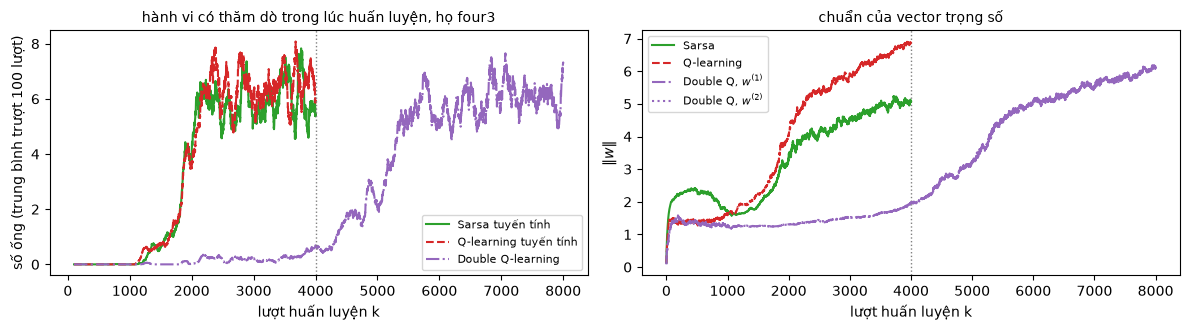

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.4))
# trái: số ống của lượt huấn luyện (hành vi có thăm dò), trung bình trượt 100 lượt
# phải: chuẩn vector trọng số theo lượt; Double Q vẽ riêng w1 và w2
curves = {"Sarsa tuyến tính": (log_sarsa["score"], ("tab:green", "-")),
          "Q-learning tuyến tính": (compare[best]["log"]["score"], ("tab:red", "--")),
          "Double Q-learning": (log_d["score"], ("tab:purple", "-."))}
for name, (sc, (col, ls)) in curves.items():
    axes[0].plot(np.arange(100, len(sc) + 1), np.convolve(sc, np.ones(100) / 100, mode="valid"), color=col, ls=ls, label=name)
for ax in axes:
    ax.axvline(K_TRAIN, color="0.5", ls=":", lw=1)                     # lượt 4000: hết ngân sách của Sarsa, Q-learning
axes[1].plot(log_sarsa["wnorm"], color="tab:green", ls="-", label="Sarsa")
axes[1].plot(compare[best]["log"]["wnorm"], color="tab:red", ls="--", label="Q-learning")
axes[1].plot(log_d["wnorm1"], color="tab:purple", ls="-.", label="Double Q, $w^{(1)}$")
axes[1].plot(log_d["wnorm2"], color="tab:purple", ls=":", label="Double Q, $w^{(2)}$")
axes[0].set_xlabel("lượt huấn luyện k"); axes[0].set_ylabel("số ống (trung bình trượt 100 lượt)")
axes[0].set_title(f"hành vi có thăm dò trong lúc huấn luyện, họ {best}", fontsize=10)
axes[1].set_xlabel("lượt huấn luyện k"); axes[1].set_ylabel(r"$\|w\|$"); axes[1].set_title("chuẩn của vector trọng số", fontsize=10)
for ax in axes:
    ax.legend(fontsize=8)
fig.tight_layout(); plt.show()

### 13.2. Đánh giá cuối

Chính sách tham lam theo tổng hai ước lượng được đánh giá trên cùng $100$ lượt `TEST_SEED` như phần 8; kết quả của bốn chính sách ở phần 8 được dùng lại, nên các hiệu ghép cặp tính trên cùng lượt.

In [27]:
final["Double Q-learning"] = evaluate(env, pol_double, N_TEST, TEST_SEED)
for name in ["luật tay", "Sarsa tuyến tính", "Q-learning tuyến tính", "Double Q-learning"]:
    summarize(name, final[name])
print()
for b_ in ["Q-learning tuyến tính", "Sarsa tuyến tính", "luật tay"]:
    m, h = paired_difference(final["Double Q-learning"], final[b_])
    print(f"Double Q-learning - {b_} (số ống): {m:6.2f} ± {h:5.2f} (khoảng 95%, ghép cặp)")

# Độ lệch max_a q(S_0, .) - G_0 trên 100 lượt TEST_SEED; Double Q dùng trung bình hai ước lượng
qbar = lambda o: 0.5 * (Q1_d.q(phi_b(o)) + Q2_d.q(phi_b(o)))
est = {"Sarsa tuyến tính": lambda o: Q_sarsa.q(phi_b(o)), "Q-learning tuyến tính": lambda o: compare[best]["Q"].q(phi_b(o)),
       "Double Q-learning": qbar}
print()
for name, qf in est.items():
    q0 = np.array([qf(env.reset(seed=TEST_SEED + i)[0]).max() for i in range(N_TEST)])
    d = q0 - final[name]["G0"]
    print(f"{name:<22} max_a q(S_0,.) = {q0.mean():6.2f}, G_0 = {final[name]['G0'].mean():6.2f}, "
          f"hiệu {d.mean():6.2f} ± {1.96 * d.std(ddof=1) / np.sqrt(N_TEST):5.2f}")

luật tay                 ống  34.30 ±  1.30 | tổng thưởng   163.4 ±   6.0 | dài  1334.0 | đạt 50 ống   23%
Sarsa tuyến tính         ống  38.04 ±  1.61 | tổng thưởng   180.2 ±   7.5 | dài  1464.6 | đạt 50 ống   55%
Q-learning tuyến tính    ống  28.86 ±  1.98 | tổng thưởng   137.5 ±   9.2 | dài  1123.0 | đạt 50 ống   34%
Double Q-learning        ống  38.24 ±  1.79 | tổng thưởng   181.1 ±   8.3 | dài  1472.1 | đạt 50 ống   56%

Double Q-learning - Q-learning tuyến tính (số ống):   9.38 ±  4.75 (khoảng 95%, ghép cặp)
Double Q-learning - Sarsa tuyến tính (số ống):   0.20 ±  4.25 (khoảng 95%, ghép cặp)
Double Q-learning - luật tay (số ống):   3.94 ±  4.06 (khoảng 95%, ghép cặp)

Sarsa tuyến tính       max_a q(S_0,.) =   7.32, G_0 =  11.41, hiệu  -4.09 ±  0.15
Q-learning tuyến tính  max_a q(S_0,.) =  11.38, G_0 =  10.65, hiệu   0.73 ±  0.40
Double Q-learning      max_a q(S_0,.) =  10.00, G_0 =  11.15, hiệu  -1.15 ±  0.27


**Đọc kết quả** (trong lần chạy này, một hạt giống huấn luyện; số theo output):

- Với $8000$ lượt huấn luyện, cùng họ `four3` và cùng $\alpha$ trên mỗi vector, chính sách tham lam theo tổng của Double Q-learning qua $38{,}24\pm1{,}79$ ống trên `TEST_SEED` ($56\%$ lượt đạt $50$ ống). Hiệu ghép cặp với Q-learning là $9{,}38\pm4{,}75$ (khoảng không chứa $0$ nhưng cận dưới sát $0$), với Sarsa $0{,}20\pm4{,}25$ và với luật tay $3{,}94\pm4{,}06$ (hai khoảng chứa $0$). Có ba khoảng tin cậy trên cùng dữ liệu, nên khoảng sát $0$ cần đọc thận trọng.
- Hai thuật toán không dùng cùng ngân sách: Double Q-learning dùng gấp đôi số lượt. Số cập nhật thực tế của mỗi vector ($552\,057$ và $551\,143$) vẫn ít hơn của vector Q-learning trong $4000$ lượt ($718\,864$), vì các lượt đầu của Double Q-learning ngắn. Theo hình ở mục 13.1, số ống của lượt huấn luyện gần $0$ tới khoảng lượt $4000$, tăng trong khoảng lượt $4500$–$6000$, rồi dao động quanh $5$–$7$ như Sarsa và Q-learning; cũng theo hình, ở lượt $4000$, $\lVert w^{(i)}\rVert$ chỉ khoảng $2$, so với $6{,}9$ của Q-learning. Vì vậy chênh lệch với Q-learning trộn hai yếu tố: bộ ước lượng kép và lượng dữ liệu gấp đôi; notebook không tách được hai yếu tố này (nhiệm vụ 1 ở phần 12).
- Độ lệch $\max_a\bar q(S_0,\cdot)-G_0$ của Double Q-learning là $-1{,}15\pm0{,}27$, nằm giữa $+0{,}73\pm0{,}40$ của Q-learning và $-4{,}09\pm0{,}15$ của Sarsa. Lần này ba chính sách có $G_0$ gần nhau ($11{,}15$; $10{,}65$; $11{,}41$), nên phép so có ý nghĩa hơn ở mục 9.2; hướng chênh lệch phù hợp với việc bộ ước lượng kép giảm đánh giá cao, nhưng đây vẫn là một hạt giống và ba chính sách khác nhau.
- Bảng thử nghiệm khi soạn (ô mã kế tiếp, hạt giống khác) cho Double Q-learning với $K=8000$ lần lượt $26{,}9$; $17{,}8$ và $0$ ống; kết quả của lần chạy này ($36{,}85$ ống trên `VALID_SEED`, $38{,}24$ trên `TEST_SEED`) cao hơn cả ba. Với $K=4000$ chỉ $1$ trong $3$ hạt giống đạt $20$ ống, và phiên bản trước của notebook (cùng hạt giống, $4000$ lượt) cho $0{,}06$ ống trên `TEST_SEED`. Kết quả của Double Q-learning vì vậy biến thiên mạnh theo hạt giống và số lượt; không rút ra kết luận chung về thứ tự giữa ba thuật toán.

In [28]:
DOUBLE_TUNE = [   # thử nghiệm ngoài notebook: (hệ số nhân alpha, K, hạt giống, số ống TB trên 100 lượt 800000+i, tỉ lệ đạt 50)
    (1, 4000, 1, 20.00, 0.12),
    (1, 4000, 2, 0.00, 0.00),
    (1, 4000, 3, 0.35, 0.00),
    (1, 8000, 1, 26.90, 0.29),
    (1, 8000, 2, 17.76, 0.12),
    (1, 8000, 3, 0.00, 0.00),
    (2, 4000, 1, 0.00, 0.00),
    (2, 4000, 2, 0.00, 0.00),
    (2, 4000, 3, 0.00, 0.00),
    (2, 8000, 1, 0.00, 0.00),
    (2, 8000, 2, 0.00, 0.00),
    (2, 8000, 3, 0.00, 0.00),
]
print("Double Q-learning trên four3, kappa = 0,5 nhân hệ số; hạt giống huấn luyện 10^6 * s; đánh giá 100 lượt hạt giống 800000+i")
print(f"{'hệ số alpha':>11}{'K':>6}{'hạt giống':>11}{'ống TB':>8}{'đạt 50':>8}")
for m, K, sd, sc, tr in DOUBLE_TUNE:
    print(f"{m:>11}{K:>6}{sd:>11}{sc:>8.2f}{tr:>8.2f}")

Double Q-learning trên four3, kappa = 0,5 nhân hệ số; hạt giống huấn luyện 10^6 * s; đánh giá 100 lượt hạt giống 800000+i
hệ số alpha     K  hạt giống  ống TB  đạt 50
          1  4000          1   20.00    0.12
          1  4000          2    0.00    0.00
          1  4000          3    0.35    0.00
          1  8000          1   26.90    0.29
          1  8000          2   17.76    0.12
          1  8000          3    0.00    0.00
          2  4000          1    0.00    0.00
          2  4000          2    0.00    0.00
          2  4000          3    0.00    0.00
          2  8000          1    0.00    0.00
          2  8000          2    0.00    0.00
          2  8000          3    0.00    0.00


### 13.3. Trực quan hóa

Lượt được vẽ là lượt đầu của `TEST_SEED`, như mục 9.1. Trình phát đặt luật tay, Sarsa, Q-learning và Double Q-learning cạnh nhau, hiển thị $600$ bước đầu; đồ thị thứ hai so $\max_a\bar q(S_t,a)$ của Double Q-learning với $G_t$ dọc lượt, như mục 9.2; hình cuối là lát cắt chính sách tham lam theo tổng hai ước lượng, cùng quan sát gốc như mục 9.3.

Double Q-learning: 46 ống, 1781 bước, va chạm


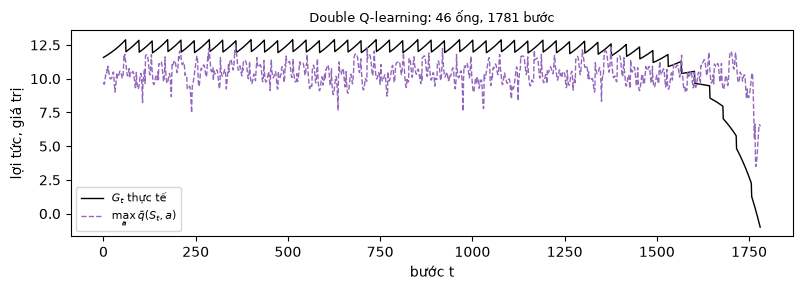

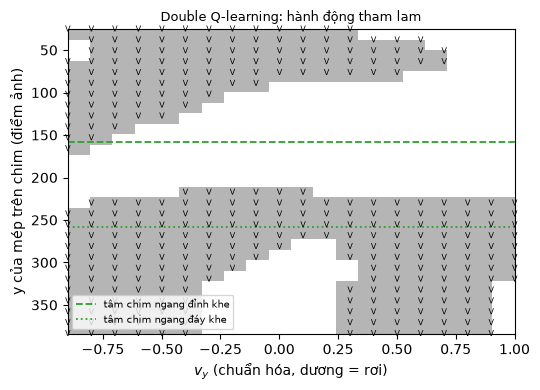

In [29]:
ep_dq = run_episode(env, pol_double, TEST_SEED + k_viz, record=True)
assert ep_dq["length"] == final["Double Q-learning"]["length"][k_viz]     # trùng lượt trong đánh giá cuối
print(f"Double Q-learning: {ep_dq['score']} ống, {ep_dq['length']} bước, " + ("đạt giới hạn" if ep_dq["truncated"] else "va chạm"))
episodes_dq = {"luật tay": episodes_final["luật tay"], "Sarsa tuyến tính": episodes_final["Sarsa tuyến tính"],
               "Q-learning tuyến tính": episodes_final["Q-learning tuyến tính"], "Double Q-learning": ep_dq}
display(flappy_player(episodes_dq, max_frames=600))   # 600 bước đầu để giữ dung lượng nhỏ

G = returns_from(ep_dq["rewards"])
qmax = np.array([qbar(o).max() for o in ep_dq["states"][:-1]])          # max_a q_bar(S_t, a)
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(G, color="k", lw=1, label="$G_t$ thực tế")
ax.plot(qmax, color="tab:purple", ls="--", lw=1, label=r"$\max_a\bar q(S_t,a)$")
ax.set_xlabel("bước t"); ax.set_ylabel("lợi tức, giá trị"); ax.legend(fontsize=8)
ax.set_title(f"Double Q-learning: {ep_dq['score']} ống, {ep_dq['length']} bước", fontsize=9)
fig.tight_layout(); plt.show()

A = np.zeros((len(ys), len(vys)))                                      # lát cắt như mục 9.3
for i, y in enumerate(ys):
    for j, vy in enumerate(vys):
        o = o_sl.copy(); o[9], o[10] = y, vy
        A[i, j] = np.argmax(Q1_d.q(phi_b(o)) + Q2_d.q(phi_b(o)))          # 1 = vỗ cánh
fig, ax = plt.subplots(figsize=(5.5, 4))
ax.imshow(A, origin="upper", aspect="auto", cmap="Greys", vmin=0, vmax=2.5,
          extent=[vys[0], vys[-1], ys[-1] * H_PX, ys[0] * H_PX])
for i, y in enumerate(ys):
    for j, vy in enumerate(vys):
        if A[i, j] == 1:
            ax.text(vy, y * H_PX, "V", ha="center", va="center", fontsize=6)
for v, lab, ls in ((o_sl[3 * k_sl + 1], "tâm chim ngang đỉnh khe", "--"), (o_sl[3 * k_sl + 2], "tâm chim ngang đáy khe", ":")):
    ax.axhline(v * H_PX - PLAYER_H * H_PX / 2, color="tab:green", ls=ls, lw=1.3, label=lab)
ax.legend(fontsize=7, loc="lower left")
ax.set_title("Double Q-learning: hành động tham lam", fontsize=9); ax.set_xlabel("$v_y$ (chuẩn hóa, dương = rơi)")
ax.set_ylabel("y của mép trên chim (điểm ảnh)")
fig.tight_layout(); plt.show()

**Đọc hình** (trong lần chạy này): ở lượt đầu của `TEST_SEED`, Double Q-learning qua $46$ ống và va chạm ở bước $1781$, cùng ống và cùng bước với Sarsa và Q-learning ở mục 9.1. Dọc lượt, $\max_a\bar q(S_t,a)$ phần lớn thấp hơn $G_t$ khoảng $1$–$3$, phù hợp với độ lệch âm đo ở mục 13.2; gần cuối lượt, khi chim sắp va chạm, ước lượng cao hơn $G_t$. Trên lát cắt, chính sách không vỗ cánh ở nửa trên của dải khe, vỗ cánh ở phần dưới dải khe và bên dưới khi chim đang rơi, và có một vùng không vỗ ở $y\gtrsim280$ điểm ảnh với $v_y$ khoảng $[-0{,}25;\,0{,}25]$; phía trên đỉnh khe, chính sách vỗ cánh ở phần lớn vùng có $v_y$ âm hoặc nhỏ, giống Sarsa và Q-learning ở mục 9.3.

### 13.4. Đối chiếu lý thuyết

Double Q-learning giảm thiên lệch dương do phép cực đại: với hai ước lượng có nhiễu độc lập, ước lượng dùng để đánh giá không cùng nhiễu với ước lượng dùng để chọn, nên $\mathbb E\big[\hat q(S',A^*,w^{(2)})\big]$ không bị đẩy lên như $\mathbb E\big[\max_a\hat q(S',a,w^{(1)})\big]$ (van Hasselt, 2010). Ở đây hai vector được học từ cùng một luồng dữ liệu nên chỉ độc lập một phần. Thuật toán vẫn có đủ ba yếu tố của bộ ba bất ổn: bootstrap, học khác chính sách (mục tiêu theo chính sách tham lam, dữ liệu theo hành vi $\varepsilon$-tham lam) và xấp xỉ hàm. Vì vậy không có bảo đảm hội tụ chung với xấp xỉ hàm tuyến tính; các số đo ở mục 13.2 là của một lần chạy với một hạt giống.

**Câu hỏi:** (a) Giải thích vì sao trong Double Q-learning, hành động $A^*$ được chọn bằng $w^{(1)}$ nhưng được đánh giá bằng $w^{(2)}$, và điều gì xảy ra nếu dùng cùng một vector cho cả hai việc. (b) Double Q-learning có loại bỏ yếu tố nào của bộ ba bất ổn hay không; nêu lý do.

<details><summary>Lời giải</summary>

(a) Nếu cùng một vector vừa chọn vừa đánh giá, mục tiêu là $\max_a\hat q(S',a,w)$; nhiễu dương của hành động được chọn đi thẳng vào mục tiêu, và vì $\mathbb E[\max]\ge\max\mathbb E$ mục tiêu bị đánh giá cao có hệ thống. Khi đánh giá bằng $w^{(2)}$, nhiễu của $w^{(2)}$ tại $A^*$ không gắn với lý do $A^*$ được chọn, nên kỳ vọng của mục tiêu không bị đẩy lên theo cách đó; kết quả có thể thấp hơn giá trị thật, tức thiên lệch có thể đổi dấu. Dùng cùng một vector cho cả hai việc chính là Q-learning thông thường.

(b) Không. Mục tiêu vẫn chứa $\hat q$ tại trạng thái kế tiếp (bootstrap), vẫn nhắm tới chính sách tham lam trong khi dữ liệu do hành vi $\varepsilon$-tham lam sinh ra (khác chính sách), và vẫn dùng hàm tuyến tính (xấp xỉ hàm). Double Q-learning sửa một nguồn thiên lệch trong mục tiêu, không đổi cấu trúc gây bất ổn.
</details>

In [30]:
print(f"Tổng thời gian chạy notebook: {time.time() - T_START:.0f} giây")

Tổng thời gian chạy notebook: 374 giây


### Tài liệu tham khảo

- Tạ Việt Cường, *Lecture 07: Hàm xấp xỉ trong Reinforcement Learning*, bài giảng gốc, tr. 24–26 (lớp hàm tuyến tính), 28–31 (biểu diễn đặc trưng, mã hóa $x(s,a)$), 32 (bán gradient), 38–39 (điều khiển), 41 (bộ ba bất ổn), 44–45 (hội tụ, tài liệu).
- Ghi chú Bài 07 của học phần: mục 5.2, 12.3–12.5, 13.1–13.3, 14.
- R. S. Sutton, A. G. Barto, *Reinforcement Learning: An Introduction*, ấn bản 2, MIT Press, 2018: §6.7 (Double Q-learning), §9.5 (xây dựng đặc trưng, gồm cơ sở Fourier và mã hóa ô chồng), §9.6 (chọn bước học), §10.1 (Sarsa bán gradient), §11.2 (ví dụ của Baird).
- G. Konidaris, S. Osentoski, P. Thomas, "Value Function Approximation in Reinforcement Learning Using the Fourier Basis", AAAI, 2011.
- J. N. Tsitsiklis, B. Van Roy, "An analysis of temporal-difference learning with function approximation", *IEEE Transactions on Automatic Control*, 42(5):674–690, 1997.
- H. van Hasselt, "Double Q-learning", NeurIPS 23, 2010.
- Môi trường: gói `flappy-bird-gymnasium` (mã nguồn `flappy_bird_env.py`, phiên bản in ở phần 1).